
<h1 style="text-align:center; color:#1B4F72; font-size:32px; font-weight:bold;">
Exploratory Data Analysis and Revenue Forecasting on Industry Data
</h1>

**Introduction:** This project analyzes company level industry data. The goal is to inspect the dataset carefully, create useful business features, perform detailed exploratory data analysis (EDA), identify outliers, study univariate, bivariate, and multivariate relationships, and then build supervised machine learning models. After reviewing the dataset, the best primary target is annual_revenue_million.

## 1. Imports the libraries

In [1]:
import os
import warnings

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor)


sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
CURRENT_YEAR = 2026

## 2. Data Loading and Initial Inspection

In [2]:
df = pd.read_csv("INDUSTRY.csv")
df_raw = df.copy()

print(f"Shape: {df.shape}")

Shape: (15000, 12)


In [3]:
df.head(10)

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia
5,6,FinTrust_6,Finance,Germany,1694,313.91,29.34,2000,41934,1.9,15-05-2024,Europe
6,7,TechNova_7,Technology,Canada,4928,565.72,35.61,2017,70154,3.6,31-10-2024,North America
7,8,RetailHub_8,Retail,USA,1634,198.82,28.41,2018,78446,2.3,07-10-2025,North America
8,9,BuildWorks_9,Manufacturing,India,3958,646.26,32.61,2014,58111,1.7,19-04-2025,Asia
9,10,MediCorp_10,Healthcare,Germany,3125,346.57,33.11,2009,69654,4.6,03-12-2025,Europe


* The dataset includes 15,000 company records and 12 features. Dataset shows a mix of numerical, categorical, and date-related features representing company characteristics, financial performance, customer information, and geographical details.
* The dataset includes key business features such as employee count, annual revenue, profit margin, customer count, market rating, and founding year. It also contains categorical information such as industry, country, and region, which can help identify business patterns across different sectors and locations.

In [4]:
print("Column data types:")
display(df.dtypes.to_frame("dtype"))

Column data types:


,dtype
id,int64
company_name,object
industry,object
country,object
employee_count,int64
annual_revenue_million,float64
profit_margin_percent,float64
founded_year,int64
customer_count,int64
market_rating,float64


* The datatype inspection confirms that the dataset contains a combination of numerical and categorical variables. Business metrics such as employee count, annual revenue, profit margin, customer count, market rating, and founded year are already stored in appropriate numerical formats.
* Additionally, the created_date column is currently stored as an object rather than a datetime format. To enable time-based analysis, this column needs to be converted into a proper datetime datatype, allowing the extraction of useful features such as month, quarter, and year.

In [5]:
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})

Missing Values per Column:


,Missing Count,Missing %
id,0,0.0
company_name,0,0.0
industry,0,0.0
country,0,0.0
employee_count,0,0.0
annual_revenue_million,0,0.0
profit_margin_percent,0,0.0
founded_year,0,0.0
customer_count,0,0.0
market_rating,0,0.0


* The missing value analysis shows that column doesn't have missing values showing that the dataset is complete and does not require any imputation. Since no missing data is present in either numerical or categorical features. This ensures that the full dataset of 15,000 observations is available for exploratory analysis, feature engineering, and machine learning without any loss of information.

In [6]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


* The duplicate record check confirmed that the dataset doesn't contain any duplicate rows showing that each observation represents a unique company record. Since no duplicate records were detected, no data removal is required.

In [7]:
df.describe(percentiles=[.05, .25, .50, .75, .95]).T.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max
id,15000.0,7500.50,4330.27,1.00,750.95,3750.75,7500.50,11250.25,14250.05,15000.00
employee_count,15000.0,2606.86,1430.56,100.00,372.95,1379.00,2587.00,3839.00,4837.00,5099.00
annual_revenue_million,15000.0,549.73,288.24,50.16,103.28,299.92,543.92,797.57,1004.32,1049.96
profit_margin_percent,15000.0,25.01,11.53,5.00,7.01,15.05,24.91,35.10,42.95,45.00
founded_year,15000.0,2004.37,8.61,1990.00,1991.00,1997.00,2004.00,2012.00,2018.00,2019.00
customer_count,15000.0,50449.25,28744.64,500.00,5643.45,25676.25,50726.50,75271.25,95221.00,100495.00
market_rating,15000.0,2.51,1.45,0.00,0.20,1.20,2.50,3.80,4.70,5.00


* Employee count ranges from 100 to 5099 with a median of 2587 showing that the dataset contains companies of varying sizes. Similarly, customer count ranges from 500 to 100495, reflecting substantial diversity in customer bases across companies.
* Annual revenue ranges from approximately 50 million to 1050 million, with a median value of 543.92 million, suggesting that revenue is distributed across a wide range of company profiles. Profit margin percentages vary between 5% and 45%, while market ratings span the full rating scale from 0 to 5, providing sufficient variation for further analysis.
The mean and median values for most numerical variables are relatively close, indicating no obvious extreme skewness from a statistical perspective. The percentile analysis also shows a gradual increase from lower to upper quartiles, suggesting that the data is reasonably well distributed across the observed ranges.

In [8]:
for col in ["industry", "country", "region"]:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().to_string())


industry — 5 unique values:
industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000

country — 4 unique values:
country
India      3750
Germany    3750
Canada     3750
USA        3750

region — 3 unique values:
region
North America    7500
Asia             3750
Europe           3750


* The categorical variable analysis shows a highly balanced distribution across all categories. Each industry category contains exactly 3,000 records, each country contains 3,750 records, and the regional distribution is proportionally divided between North America, Asia, and Europe.
* The distribution also shows that the dataset is designed to provide equal coverage across major business sectors and geographical locations. As a result, any differences observed during later analysis are more likely to reflect actual patterns in the data rather than biases caused by unequal category frequencies.

In [9]:
df["created_date"]    = pd.to_datetime(df["created_date"], dayfirst=True, errors="coerce")
print(df["created_date"].dtype)
df["created_date"].head()

datetime64[ns]


0   2025-10-13
1   2025-12-01
2   2025-05-04
3   2026-02-01
4   2025-06-29
Name: created_date, dtype: datetime64[ns]

* The `created_date` column is successfully converted from a object format to a proper datetime format. This conversion is an important preprocessing step because datetime values can be used to extract meaningful temporal information that is not directly available in the original column. This enables the creation of additional time-based features such as month, quarter, and year, which may help identify seasonal or temporal business patterns during exploratory analysis and model development.
* By converting the date column before feature engineering, the dataset becomes better structured for analysis and ensures that time-related information can be utilized effectively in subsequent stages of the project.

## 3. Target Variable Analysis 

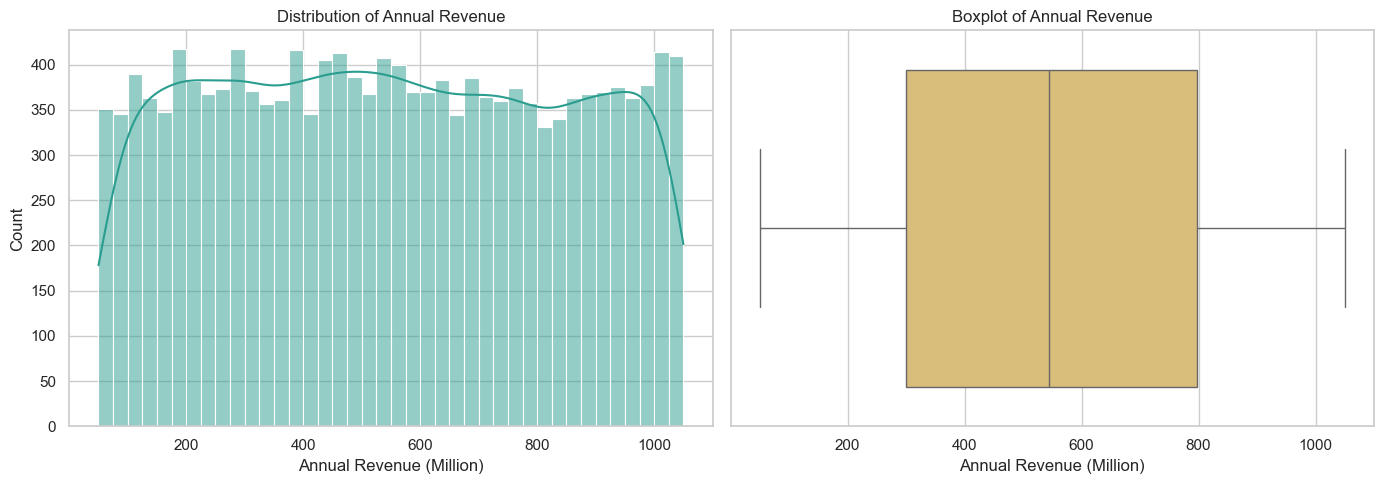

,annual_revenue_million
count,15000.000
mean,549.733
std,288.244
min,50.160
25%,299.915
50%,543.920
75%,797.570
max,1049.960


Skewness: 0.0273
Kurtosis: -1.1871


In [10]:
target = "annual_revenue_million"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target], bins=40, kde=True, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Distribution of Annual Revenue")
axes[0].set_xlabel("Annual Revenue (Million)")

sns.boxplot(x=df[target], ax=axes[1], color="#E9C46A")
axes[1].set_title("Boxplot of Annual Revenue")
axes[1].set_xlabel("Annual Revenue (Million)")

plt.tight_layout()
plt.show()

display(df[target].describe().to_frame("annual_revenue_million").round(3))
print(f"Skewness: {df[target].skew():.4f}")
print(f"Kurtosis: {df[target].kurt():.4f}")

* The target variable `annual_revenue_million`, shows a broad distribution ranging from approximately 50 million to 1,050 million, with an average revenue of 549.73 million and a median of 543.92 million.
* The histogram shows that revenue values are spread relatively evenly across the observed range rather than being concentrated in a particular interval. This observation is supported by the skewness value (0.0273), which is very close to zero and indicates an almost symmetric distribution.
* The kurtosis value (-1.1871) suggests a flatter distribution compared to a normal distribution, with fewer extreme observations.
* The boxplot further confirms the absence of significant outliers, as no unusual observations appear beyond the whiskers. This indicates that the target variable is well distributed and does not require transformations such as logarithmic scaling or aggressive outlier treatment before model development.

## 4. Correlation With Target
This step is important because it checks the predictive signal using only original, valid input variables. If these correlations are weak, then a supervised model should also be expected to perform weakly.

,pearson_correlation,absolute_correlation
market_rating,0.01464,0.01464
founded_year,-0.01184,0.01184
profit_margin_percent,-0.00312,0.00312
customer_count,-0.00267,0.00267
employee_count,-0.00204,0.00204


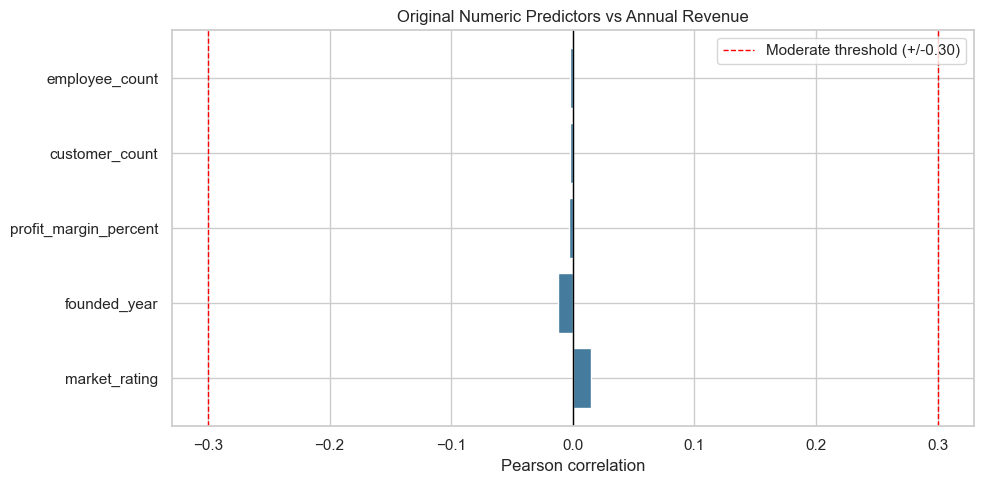

Maximum absolute correlation with revenue among original numeric predictors: 0.01464


In [11]:
original_numeric_predictors = [
    "employee_count",
    "profit_margin_percent",
    "founded_year",
    "customer_count",
    "market_rating",
]

target_corr = (
    df[original_numeric_predictors + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_table = target_corr.to_frame("pearson_correlation")
corr_table["absolute_correlation"] = corr_table["pearson_correlation"].abs()
display(corr_table.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#D62828" if abs(v) >= 0.3 else "#457B9D" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.3, color="red", linestyle="--", linewidth=1, label="Moderate threshold (+/-0.30)")
ax.axvline(-0.3, color="red", linestyle="--", linewidth=1)
ax.set_title("Original Numeric Predictors vs Annual Revenue")
ax.set_xlabel("Pearson correlation")
ax.legend()
plt.tight_layout()
plt.show()

max_abs_corr = corr_table["absolute_correlation"].max()
print(f"Maximum absolute correlation with revenue among original numeric predictors: {max_abs_corr:.5f}")

* Pearson correlation analysis is performed to evaluate the linear relationship between the original numerical predictors and the target variable,vannual_revenue_million. The results show that all correlation values are extremely close to zero, with the highest absolute correlation being observed for market_rating (0.01464), followed by founded_year (0.01184). The remaining variables, including employee count, customer count, and profit margin percentage, exhibit even weaker relationships with annual revenue.
* The correlation chart further confirms that none of the predictors approach the commonly used threshold of ±0.30, which is often considered the minimum level for a moderate linear relationship. This suggests that the available numerical variables do not have a meaningful linear influence on annual revenue within the dataset.
* This is important because it indicates that predicting annual revenue using only the original numerical features may be challenging.
* The weak correlations suggest that either the target variable is largely independent of the available predictors or that any existing relationships are non-linear and cannot be captured through simple correlation analysis.

## 5. Feature engineering

In [12]:
df["created_month"]   = df["created_date"].dt.month
df["created_quarter"] = df["created_date"].dt.quarter
df["created_year"]    = df["created_date"].dt.year
df[["created_date","created_month","created_quarter","created_year"]].head()

,created_date,created_month,created_quarter,created_year
0,2025-10-13,10,4,2025
1,2025-12-01,12,4,2025
2,2025-05-04,5,2,2025
3,2026-02-01,2,1,2026
4,2025-06-29,6,2,2025


* The `created_date` column is converted into three separate features such as created_month, created_quarter, and created_year. This was done to make the date information easier to analyze and use in machine learning models.
These new features allow us to examine whether companies created during different months, quarters, or years show any differences in annual revenue or other business metrics. Working with month, quarter, and year separately is often more useful than using the complete date value.
Creating these time-based features helps us explore possible seasonal and time-related patterns in the dataset and prepares the data for further analysis and feature engineering.

In [13]:
current_year = df["created_year"].max()
df["company_age"] = current_year - df["founded_year"]
df[["founded_year", "company_age"]].head(10)

,founded_year,company_age
0,2010,16
1,2010,16
2,1996,30
3,1993,33
4,1996,30
5,2000,26
6,2017,9
7,2018,8
8,2014,12
9,2009,17


* A new feature called `company_age` is created by subtracting the company's founding year from the most recent year available in the dataset. This feature represents how long a company has been operating.
* Older companies may have more experience, a larger customer base, stronger brand recognition, and more stable operations compared to newer companies. Therefore, company age may provide additional information that is not directly visible from the founding year alone.
* Using company age also makes the data easier to interpret. This feature may help identify whether company maturity has any relationship with annual revenue or other business performance indicators.

In [14]:
df["company_age"].describe().round(2)

count    15000.00
mean        21.63
std          8.61
min          7.00
25%         14.00
50%         22.00
75%         29.00
max         36.00
Name: company_age, dtype: float64

In [15]:
df.groupby("company_age")["annual_revenue_million"].mean().head()

company_age
7     523.159571
8     543.614449
9     535.563290
10    542.106815
11    560.650115
Name: annual_revenue_million, dtype: float64

In [16]:
age_revenue = df.groupby("company_age")["annual_revenue_million"].mean().round(2)
print(age_revenue)

company_age
7     523.16
8     543.61
9     535.56
10    542.11
11    560.65
12    570.92
13    553.40
14    543.56
15    543.07
16    533.79
17    534.31
18    548.19
19    545.14
20    563.36
21    551.57
22    563.58
23    569.47
24    564.42
25    544.50
26    552.94
27    527.00
28    562.63
29    557.32
30    535.20
31    551.54
32    534.43
33    564.61
34    552.83
35    562.93
36    554.70
Name: annual_revenue_million, dtype: float64


* The new feature `company_age` ranges from 7 to 36 years, with an average age of approximately 22 years. This shows that the dataset contains a mix of relatively young and well-established companies.
* To understand whether company age influences revenue, the average annual revenue is calculated for each age group. The results show that revenue values fluctuate across different company ages, but no clear increasing or decreasing trend is visible. Both younger and older companies appear to generate similar levels of revenue on average.
* This suggests that company age alone may not be a strong predictor of annual revenue in this dataset. However, the feature still provides useful business context and may contribute additional information when combined with other variables during machine learning model development.

In [17]:
df["revenue_per_employee"]  = df["annual_revenue_million"] / df["employee_count"]
df[["revenue_per_employee"]].head(10)

,revenue_per_employee
0,1.008187
1,0.223967
2,0.092519
3,0.370228
4,0.220196
5,0.185307
6,0.114797
7,0.121677
8,0.163279
9,0.110902


* A new feature called `revenue_per_employee` is created by dividing annual revenue by the number of employees. This feature measures the average revenue generated by each employee and can be used as an indicator of operational efficiency.
* Companies with a higher revenue per employee may be utilizing their workforce more effectively, while lower values may indicate lower productivity or larger workforce requirements relative to revenue generation. This feature provides additional business insight that cannot be observed directly from revenue or employee count alone.
* The calculated values show noticeable variation across companies suggesting differences in how efficiently organizations convert their workforce into revenue. 

In [18]:
df["revenue_per_customer"]  = (
    df["annual_revenue_million"] / df["customer_count"]
) * 1_000_000
df[["revenue_per_customer"]].head(10)

,revenue_per_customer
0,6.643347e+03
1,9.249148e+03
2,9.338588e+03
3,3.404063e+03
4,1.163153e+06
5,7.485811e+03
6,8.063974e+03
7,2.534482e+03
8,1.112113e+04
9,4.975594e+03


* A new feature `revenue_per_customer` is created by dividing annual revenue by number of customers. It estimates average revenue earned from a single customer and helps quantify customer value.
* The feature tells how well a company monetizes its users. A larger number could indicate that each customer brings in more revenue on average, whereas a smaller number could mean revenue is spread over more customers.
* The resulting numbers vary widely between companies, reflecting different customer expenditure and business model. This may be particularly useful in identifying those companies which derive more revenue per customer, and even provide some further indication of business performance overall.

In [19]:
df["customer_per_employee"] = (
    df["customer_count"] / df["employee_count"]
)
df[["customer_per_employee"]].head(10)

,customer_per_employee
0,151.758879
1,24.214924
2,9.907161
3,108.760479
4,0.189310
5,24.754427
6,14.235795
7,48.008568
8,14.681910
9,22.289280


* A new feature `customer_per_employee` is created by dividing the total customers by the total employees. The value corresponds to the average number of customers that are served by an employee, and it gives a sense of how efficient the business is running.
* The metric indicates how well a company turns its workforce into a customer base. A higher ratio means that an employee has to handle more customers, and a lower customer to employee ratio means the employee is handling fewer customers.
* There is a considerable both minimum and maximum value in the sample values for the entire set of companies, indicating variability in how these firms run their businesses, employ their workforces, and manage their customers. As this feature is a combination of two major business figures and is not dependent on the target variable, it could include extra information that helps understanding company performance and hence enable accurate prediction, and it should be a potential feature for machine learning analysis. 

In [20]:
df[
    [
        "revenue_per_employee",
        "revenue_per_customer",
        "customer_per_employee"
    ]
].describe().round(2)

,revenue_per_employee,revenue_per_customer,customer_per_employee
count,15000.00,15000.00,15000.00
mean,0.42,28581.44,39.07
std,0.75,78542.97,69.92
min,0.01,545.49,0.12
25%,0.11,5863.81,9.79
50%,0.21,10884.05,19.26
75%,0.40,21423.52,36.94
max,10.32,1696219.71,891.97


### Summary statistics 
* The engineered variables vary significantly at the company level reflecting differences in operating efficiency and customer management between firms. Magnitude of variation in these features The fact that these features attained such extreme values, indicates that companies are based on different business models and are performing very different levels. `revenue_per_customer` has with the greatest spread, ranging from about 545 to 1.7 million. The big difference between the median and the max indicates that a small number of companies have very high revenue per customer. Also, `customer_per_employee` differs significantly from company to company, implying that there are great variations in how the workforce is utilized and number of customers served.
* Such diversity in the engineered features is a good thing, as in general, machine learning models learn better from features that capture interesting variation. These properties will be further investigated to find whether they hold useful predictive information about company performance and revenue patterns. 

In [21]:
df["profit_score"] = df["profit_margin_percent"] * df["market_rating"]
df[
    [
        "profit_margin_percent",
        "market_rating",
        "profit_score"
    ]
].head(10)

,profit_margin_percent,market_rating,profit_score
0,40.42,0.7,28.294
1,39.55,3.4,134.470
2,23.68,2.9,68.672
3,31.31,0.9,28.179
4,43.65,0.5,21.825
5,29.34,1.9,55.746
6,35.61,3.6,128.196
7,28.41,2.3,65.343
8,32.61,1.7,55.437
9,33.11,4.6,152.306


* A new feature `Profit_score` is created by combining profit margin percentage and market rating. This is meant to represent financial performance and market view in a single variable.
* The rationale for this feature is that companies with higher profit margin and higher market rating may be more efficient and have better customers or market satisfaction. By blending these two business measures, the new feature captures a more complete overview of company performance than either one on its own.
* The sample values exhibit strong variations across companies, suggesting that there is a substantial diversity in how companies combine profitability with market reputation. This engineered feature may reveal patterns that are missed when considering separately the profit margin and the market rating, and the same will be analyzed further during exploratory analysis/model building. 

In [22]:
df["revenue_tier"] = pd.qcut(df["annual_revenue_million"], q=3, labels=["Low", "Medium", "High"])
df["revenue_tier"].value_counts()

revenue_tier
Low       5000
Medium    5000
High      5000
Name: count, dtype: int64

* A new categorical feature named `revenue_tier` is created by dividing the companies into three categories according to their yearly revenue such as low, medium, and high. The division is made at quantiles of equal size, with each bucket containing 5000 companies exactly.
* Comparing and analyzing companies within a revenue range simplifies the process instead of having to compare directly all the time with each individual revenue number. The methodology may be used to explore potential differences in business and customer behavior, as well as business outcomes among low-, medium- and high-revenue firms.
* Having an equal split between the three tiers is nice for comparative analysis, as each tier has the same number of observations. These two buckets can be used in the rest of the exploratory where you need to check if other business metric changed systematically with revenues. 

In [23]:
df.groupby("revenue_tier")["annual_revenue_million"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
revenue_tier,,,,,,,,
Low,5000.0,218.95,95.54,50.16,136.57,218.30,299.88,384.54
Medium,5000.0,545.82,94.02,384.58,464.76,543.92,626.46,711.60
High,5000.0,884.43,99.07,711.79,797.57,886.85,971.92,1049.96


* The revenue tier analysis confirms a clear demarcation of low, medium and high revenue firms. Firms in the Low category have average annual revenue equal to about 219 million, while those in the Medium and High levels have about 546 million and 884 million, respectively.
* The summary statistics show a steady increase in revenues associated with the three groups, which is in line with the notion that the tiering procedure effectively separate firms based on their revenues. Also the revenue bands for each tier are still mostly separated with only a little bit of overlap at window.
* This classification gives us a convenient way to further analyze, as business characteristics, customer metrics, profitability measures and market ratings can be compared across different revenue groups. Later, these tiers can serve to examine if there is a particular operational or financial behavior associated with higher-revenue firms as opposed to lower-revenue firms. 

In [24]:
df["high_performer"] = (
    (df["profit_margin_percent"] > df["profit_margin_percent"].median()) &
    (df["market_rating"]         > df["market_rating"].median())
).astype(int)
df["high_performer"].value_counts()

high_performer
0    11295
1     3705
Name: count, dtype: int64

In [25]:
df[
    [
        "profit_margin_percent",
        "market_rating",
        "high_performer"
    ]
].head(10)

,profit_margin_percent,market_rating,high_performer
0,40.42,0.7,0
1,39.55,3.4,1
2,23.68,2.9,0
3,31.31,0.9,0
4,43.65,0.5,0
5,29.34,1.9,0
6,35.61,3.6,1
7,28.41,2.3,0
8,32.61,1.7,0
9,33.11,4.6,1


* A new feature `high_performer`, is introduced to represent well-performing companies in terms of financials and market. Rather than treating high profits or high market rating as sufficient conditions, a firm is a high performer only if its profit margin percentage and its market rating are simultaneously above the median.
* A high profit margin business with poor market ratings may have issues with customer satisfaction or a bad reputation, while a strong rated but unprofitable company may have money troubles. This feature, by requiring both conditions, also points out those companies which are fairly balanced in terms of these aspects of business.
* The results indicate that a total of 3,705 firms are in the high_performer category and 11,295 are not successful by the two measures. This segmentation allows for a nice distinction between companies that deliver both good operational results and receive a solid stamp of approval from the market, and then compare further with revenue and other business metrics. 

In [26]:
df["profit_million"] = (
    df["annual_revenue_million"] *
    df["profit_margin_percent"] / 100
)
df[
    [
        "profit_million",
        "annual_revenue_million",
        "profit_margin_percent"
    ]
].head(10)

,profit_million,annual_revenue_million,profit_margin_percent
0,218.017396,539.38,40.42
1,337.132110,852.42,39.55
2,60.883648,257.11,23.68
3,96.791734,309.14,31.31
4,431.558820,988.68,43.65
5,92.101194,313.91,29.34
6,201.452892,565.72,35.61
7,56.484762,198.82,28.41
8,210.745386,646.26,32.61
9,114.749327,346.57,33.11


* A new feature `profit_million` is created to measure the real profit earned by each firm. Profit gives a more accurate view of financial performance because it indicates the portion of the year’s revenue that remains after the business has been operated. This is a combination of revenue and profit margin, so you can view company size and profitability at the same time.  For instance, two companies could have about the same amount of revenue, but the company with a higher profit margin makes more money. In the same way, a company can have a fairly low profit margin and still make a lot of profit if it has a large enough revenue.
* The values differ substantially among the firms, which means that there is not only a diversity in revenues but also in efficiencies. This is a more comprehensive view into business performance and helps one to locate firms which not just sales revenue but also effectively converts that sales revenue into profits. 

In [27]:
df["profit_per_employee"] = (
    df["profit_million"] * 1_000_000 /
    df["employee_count"]
).round(2)
df[
    [
        "profit_per_employee",
        "profit_million",
        "employee_count"
    ]
].head(10)

,profit_per_employee,profit_million,employee_count
0,407509.15,218.017396,535
1,88579.11,337.132110,3806
2,21908.47,60.883648,2779
3,115918.24,96.791734,835
4,96115.55,431.558820,4490
5,54369.06,92.101194,1694
6,40879.24,201.452892,4928
7,34568.40,56.484762,1634
8,53245.42,210.745386,3958
9,36719.78,114.749327,3125


* Companies can generate similar profits while operating with very different workforce sizes. To account for this difference, profit was examined on a per-employee basis. This metric highlights how much profit is generated, on average, by each member of the workforce.
* The results reveal noticeable differences across companies, suggesting that some organizations are able to convert their human resources into profit more efficiently than others. Looking at profit from this perspective provides a more meaningful comparison between small and large companies than total profit alone.
* This measure adds another dimension to business performance analysis by focusing on workforce productivity rather than overall company size. It can help identify organizations that achieve strong financial results with relatively efficient use of employees.

In [28]:
df["company_size"] = pd.cut(
    df["employee_count"],
    bins=[0, 500, 1500, 3500, np.inf],
    labels=["Small", "Mid", "Large", "Enterprise"]
)
df["company_size"].value_counts()

company_size
Large         6120
Enterprise    4788
Mid           2953
Small         1139
Name: count, dtype: int64

* Not all companies in the dataset operate at the same scale. To better understand differences in business size, companies were grouped into four categories based on their employee count: Small, Mid, Large, and Enterprise.
* The distribution shows that most companies belong to the Large and Enterprise categories, while relatively fewer companies fall into the Small category. This suggests that the dataset is primarily composed of medium-to-large organizations rather than very small businesses.
* Grouping companies by size makes it easier to compare business performance across different scales of operation. It also provides a more intuitive way to analyze workforce-related patterns than using raw employee counts alone. In the following analysis, company size can be used to examine whether larger organizations differ from smaller ones in terms of revenue, profitability, customer base, and market performance.

In [29]:
df.groupby("company_size")["employee_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
Small,1139.0,304.05,118.53,100.0,202.00,307.0,409.0,500.0
Mid,2953.0,1002.65,285.93,501.0,765.00,1004.0,1250.0,1500.0
Large,6120.0,2488.02,578.23,1501.0,1984.00,2468.0,2993.0,3500.0
Enterprise,4788.0,4295.97,458.37,3501.0,3894.75,4309.0,4687.0,5099.0


* The company size categories successfully separate organizations into distinct business scales. Small companies have an average workforce of approximately 304 employees, while Enterprise companies employ an average of more than 4,295 employees. The gradual increase in employee counts across the four groups confirms that the classification captures meaningful differences in organizational size.
* The summary statistics also show relatively limited overlap between categories, indicating that each size group represents a clearly defined segment of businesses. This makes comparisons between Small, Mid, Large, and Enterprise companies more reliable and easier to interpret.
* By organizing companies into size-based segments, subsequent analyses can move beyond individual employee counts and focus on broader business patterns. This allows us to investigate whether operational performance, customer reach, profitability, and revenue characteristics differ across organizations of different scales.

In [30]:
df["customer_size"] = pd.cut(
    df["customer_count"],
    bins=[0, 10000, 30000, 70000, np.inf],
    labels=[
        "Low customer base",
        "Medium customer base",
        "High customer base",
        "Very high customer base"
    ]
)
df["customer_size"].value_counts()

customer_size
High customer base         6027
Very high customer base    4548
Medium customer base       3004
Low customer base          1421
Name: count, dtype: int64

* Customer base sizes vary considerably across the companies in the dataset. The largest share of companies falls into the High customer base category, followed by the Very high customer base group, indicating that many organizations serve a substantial number of customers.
* The distribution also shows that fewer companies belong to the Low customer base category, suggesting that smaller customer bases are less common within this dataset. This spread across different customer segments provides a useful way to analyze how business performance changes as the number of customers grows.
* Rather than comparing individual customer counts, these categories make it easier to study companies with similar customer reach. This can help reveal whether organizations serving larger customer bases differ in revenue, profitability, market ratings, or operational efficiency compared to those with fewer customers.

In [31]:
df.groupby("customer_size")["customer_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
customer_size,,,,,,,,
Low customer base,1421.0,5304.74,2782.40,500.0,2866.0,5288.0,7734.0,9999.0
Medium customer base,3004.0,20039.44,5832.96,10001.0,14988.0,20077.0,25114.5,29998.0
High customer base,6027.0,50122.22,11538.97,30001.0,40079.0,50384.0,59990.0,69999.0
Very high customer base,4548.0,85073.81,8778.57,70014.0,77514.0,85054.5,92577.0,100495.0


* The customer size classification creates a clear separation between companies with smaller and larger customer bases. The average customer count increases steadily across the four groups, ranging from approximately 5,305 customers in the Low customer base segment to more than 85,000 customers in the Very high customer base segment.
* The summary statistics indicate that each category represents a distinct level of customer reach, with minimal overlap between neighboring groups. This suggests that the segmentation successfully captures meaningful differences in market scale and customer coverage.
* Viewing companies through customer size segments provides additional business context that is not immediately visible from raw customer counts. These groups can be used to examine whether companies with broader customer reach exhibit different revenue patterns, profitability levels, or operational characteristics compared to organizations serving smaller customer populations.

In [32]:
NUM_COLS = ["employee_count","annual_revenue_million","profit_margin_percent", 
            "customer_count","market_rating","founded_year", "revenue_per_employee", "revenue_per_customer", "customer_per_employee",
            "company_age","profit_score", "profit_million", "profit_per_employee"]

stats_df = df[NUM_COLS].describe(percentiles=[.05,.25,.5,.75,.95]).T
stats_df["skewness"] = df[NUM_COLS].skew().round(4)
stats_df["kurtosis"] = df[NUM_COLS].kurt().round(4)
stats_df["CV%"]      = (df[NUM_COLS].std() / df[NUM_COLS].mean() * 100).round(2)
stats_df[["mean","std","skewness","kurtosis","CV%","min","max"]].round(3)

,mean,std,skewness,kurtosis,CV%,min,max
employee_count,2606.862,1430.563,0.002,-1.188,54.88,100.000,5099.000
annual_revenue_million,549.733,288.244,0.027,-1.187,52.43,50.160,1049.960
profit_margin_percent,25.012,11.526,0.003,-1.203,46.08,5.000,45.000
customer_count,50449.252,28744.639,-0.005,-1.195,56.98,500.000,100495.000
market_rating,2.514,1.448,-0.020,-1.206,57.60,0.000,5.000
founded_year,2004.374,8.607,0.021,-1.190,0.43,1990.000,2019.000
revenue_per_employee,0.423,0.747,5.583,42.236,176.55,0.010,10.320
revenue_per_customer,28581.435,78542.968,9.340,118.944,274.80,545.489,1696219.709
customer_per_employee,39.069,69.916,5.280,37.194,178.96,0.120,891.971
company_age,21.626,8.607,-0.021,-1.190,39.80,7.000,36.000


* The statistical summary reveals that most of the original business variables, including employee count, annual revenue, customer count, market rating, and profit margin percentage, have skewness values close to zero. This indicates that these features are relatively balanced and do not show strong asymmetry in their distributions.
* In contrast, several engineered features such as revenue_per_employee, revenue_per_customer, customer_per_employee, and profit_per_employee exhibit high positive skewness and large coefficients of variation. This suggests that while most companies fall within a typical range, a smaller number of companies have exceptionally large values for these metrics.
* The kurtosis values support this observation, particularly for revenue_per_customer and profit_per_employee, where a small number of extreme observations create heavier tails than those seen in the original variables. These findings indicate that the engineered features capture additional variability and business differences that are not immediately visible in the raw data.
* Understanding these distribution characteristics is important because highly skewed features may require closer examination during outlier analysis and model development. The next step is to investigate these distributions visually and determine whether any treatment or transformation is necessary before training machine learning models.

## 6. Univariate analysis

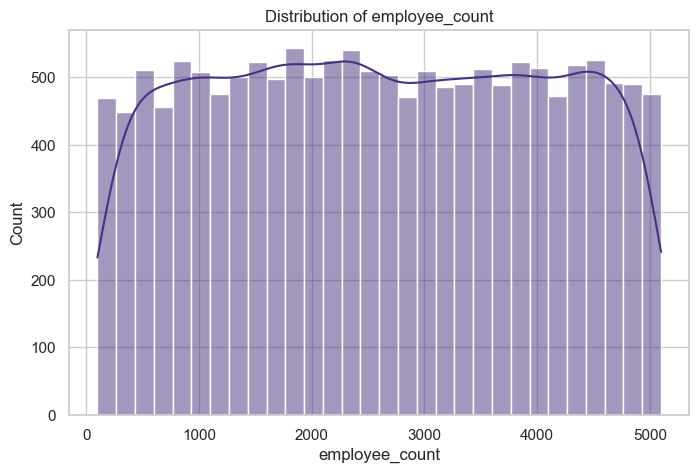

In [33]:
col = "employee_count"

plt.figure(figsize=(8,5))

sns.histplot(
    df[col],
    bins=30,
    kde=True
)

plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Count")

plt.show()

* The distribution of `employee count` is relatively uniform across the dataset, with companies spread throughout the range of approximately 100 to 5,000 employees. No particular employee range dominates the distribution, indicating that the dataset contains a balanced mix of small, medium, and large organizations.
* The histogram does not show strong skewness or unusual peaks, suggesting that workforce sizes are evenly represented rather than concentrated within a narrow interval. This balanced distribution is beneficial for analysis because it allows workforce-related patterns to be examined across a wide variety of company sizes.
* Since employee counts are well distributed and do not exhibit obvious irregularities, the feature can be used confidently in subsequent exploratory analysis and machine learning without requiring major preprocessing or transformation.

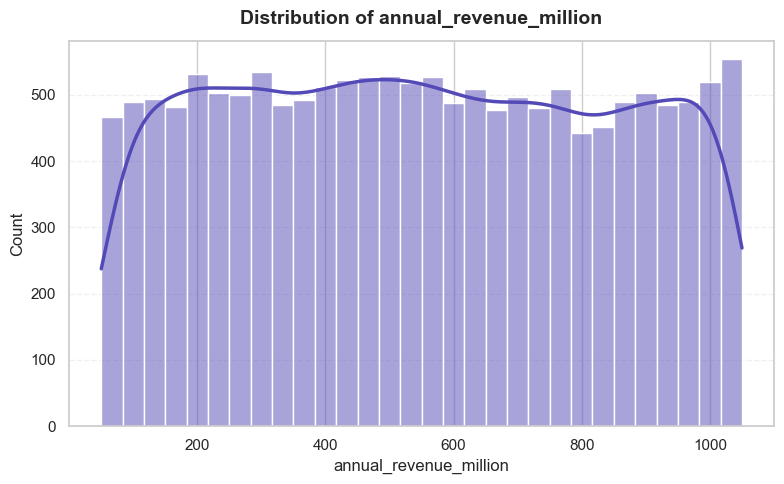

In [34]:
col = "annual_revenue_million"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#534AB7",
    line_kws={"color": "#D85A30", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* `Annual revenue` is distributed across a wide range of values, from approximately 50 million to 1,050 million. The histogram shows that companies are represented fairly evenly throughout this range, with no single revenue segment dominating the dataset.
* The distribution does not exhibit strong skewness or extreme concentration at either end of the scale. This suggests that the dataset contains a balanced mix of lower-, medium-, and higher-revenue companies, providing good coverage of different business sizes and revenue levels.
* From a modeling perspective, this is a positive characteristic because the target variable is well distributed across its range. The absence of major imbalances reduces the risk of models becoming biased toward a particular revenue segment and allows performance to be evaluated across a broader spectrum of companies.

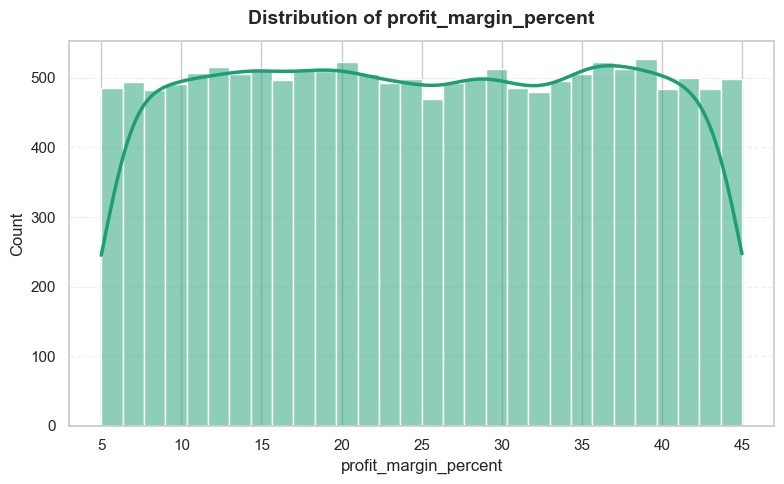

In [35]:
col = "profit_margin_percent"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#1D9E75",
    line_kws={"color": "#BA7517", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The `profit margin percentages` are spread fairly evenly across the range of 5% to 45%, indicating that the dataset includes companies with varying levels of profitability. No particular profit margin range dominates the distribution, suggesting a balanced representation of both lower- and higher-margin businesses.
* The distribution appears relatively stable without strong skewness or unusual concentration of values. This indicates that profit margin is well represented across its entire range and is unlikely to introduce bias toward any specific profitability level.
* Such variation is valuable for analysis because it allows the relationship between profitability and other business metrics, such as revenue, customer base, and market rating, to be explored across a diverse set of companies.

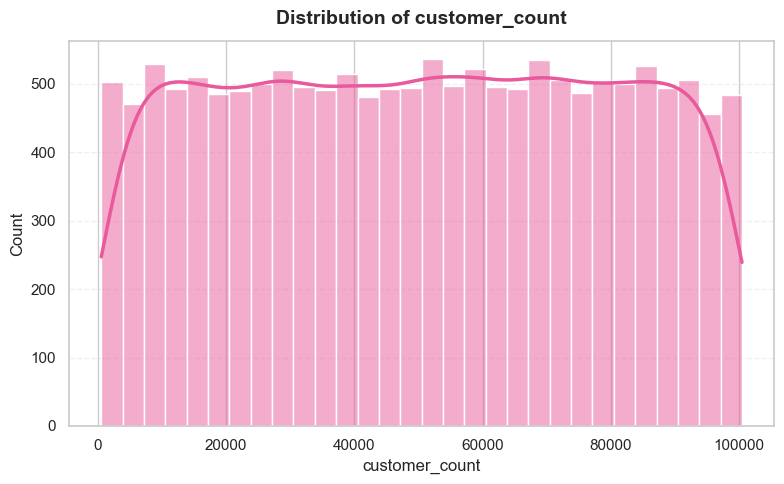

In [36]:
col = "customer_count"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#E85A9B",
    line_kws={"color": "#0C447C", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The `customer count` distribution shows that companies in the dataset serve a wide range of customers, from a few hundred to more than 100,000. The observations are spread throughout the entire range, indicating that the dataset includes businesses with both limited and extensive customer reach.
* Unlike many real-world datasets where most companies are concentrated in a specific customer segment, the customer counts here are represented across multiple scales. This diversity is useful because it allows customer-related patterns to be examined across different business sizes and market reaches.
* The broad coverage of customer counts provides a strong foundation for exploring questions such as whether companies with larger customer bases generate higher revenue, achieve better market ratings, or exhibit different profitability characteristics compared to companies serving fewer customers.

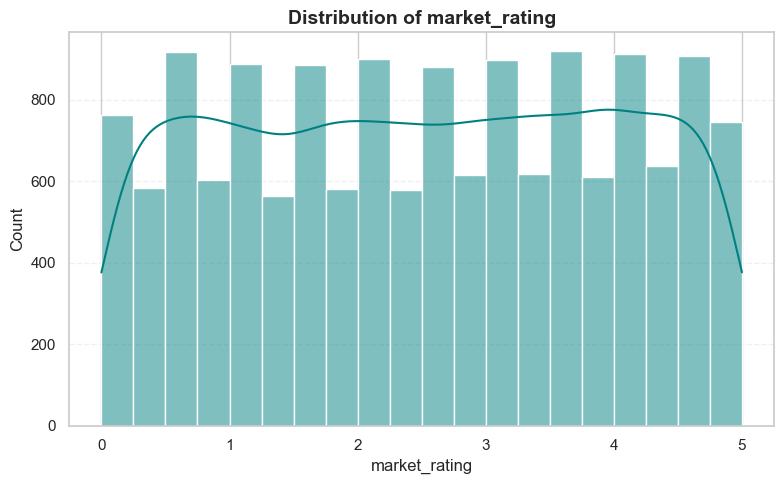

In [37]:
col = "market_rating"

plt.figure(figsize=(8,5))

sns.histplot(
    df[col],
    bins=20,
    kde=True,
    color="teal"
)

plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold")
plt.xlabel(col)
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

* Market ratings cover the entire scale from 0 to 5, indicating that the dataset includes companies with a wide variety of market perceptions. Ratings are distributed across both lower and higher values rather than being concentrated in a narrow range.
* The distribution suggests that companies with poor, average, and excellent market ratings are all represented in meaningful numbers. This diversity is valuable because it allows the analysis to investigate whether customer perception and market reputation have any relationship with revenue, profitability, or other business metrics.
* Since the ratings span the full available range, the feature provides sufficient variation for both exploratory analysis and machine learning. This makes market rating a useful variable for examining how external perception aligns with overall business performance.

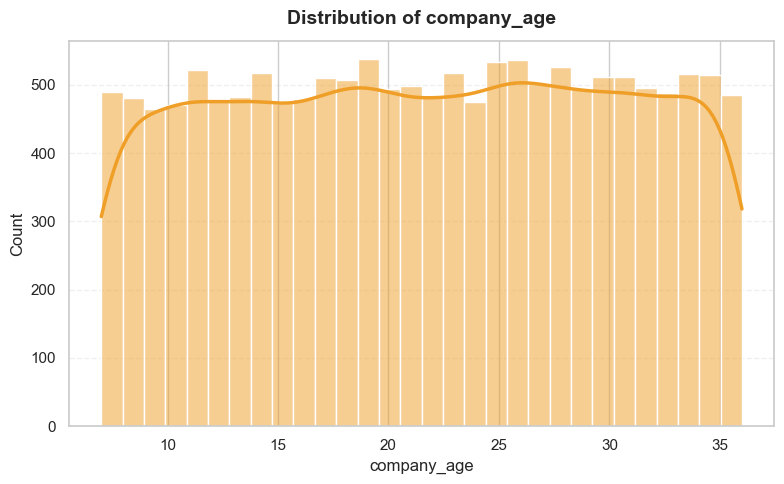

In [38]:
col = "company_age"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#EF9F27",
    line_kws={"color": "#534AB7", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `company age` shows that the dataset contains organizations ranging from relatively young businesses to long-established companies. Companies between 7 and 36 years old are represented throughout the dataset, providing a broad view of different stages of business maturity.
* No particular age group dominates the distribution, indicating that the dataset is not heavily focused on either newly established companies or older organizations. This balanced representation allows comparisons to be made across businesses with different levels of experience and market presence.
* From an analytical perspective, company age may help us explore whether business maturity influences factors such as revenue generation, profitability, customer reach, or market reputation. Examining these relationships can provide insight into whether older companies have advantages over younger competitors within this dataset.

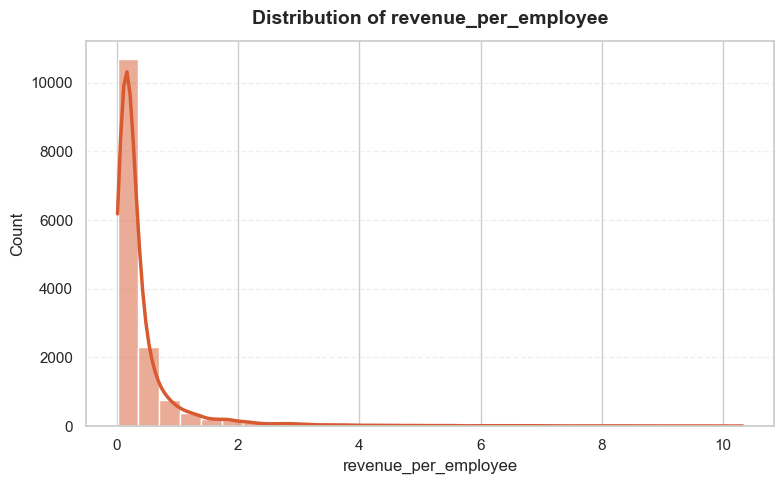

In [39]:
col = "revenue_per_employee"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#D85A30",
    line_kws={"color": "#1D9E75", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `revenue_per_employee` is heavily concentrated at lower values, with most companies generating relatively similar revenue per employee. However, a small number of companies achieve substantially higher values, creating a long right tail in the distribution.
* This pattern indicates that while the majority of organizations operate within a typical efficiency range, a few companies generate exceptionally high revenue relative to their workforce size. These observations may represent highly productive businesses or companies with business models that require fewer employees to generate revenue.
* The strong right skew observed in this feature is consistent with the statistical analysis conducted earlier. Such distributions are common for ratio-based metrics because small differences in revenue or workforce size can produce large changes in the resulting values. This feature may contain valuable information about operational efficiency, but its extreme values should be monitored during further analysis and model development.

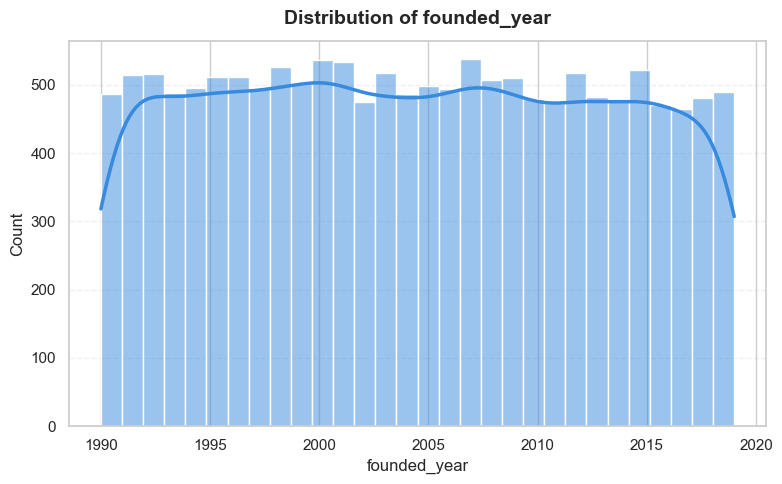

In [40]:
col = "founded_year"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#378ADD",
    line_kws={"color": "#D4537E", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `founded_year` indicates that companies were established throughout the period from 1990 to 2019, with no single time period dominating the dataset. Organizations founded in earlier years and more recent years are represented in fairly similar numbers.
* This balanced spread suggests that the dataset includes businesses from multiple generations, ranging from long-established companies to relatively newer entrants. As a result, the analysis is not overly influenced by a particular founding period.
* The presence of companies founded across nearly three decades provides an opportunity to examine whether business age and market experience are associated with differences in revenue, profitability, customer reach, or market ratings. Since all periods are reasonably represented, comparisons across different company generations can be made without major concerns about data imbalance.

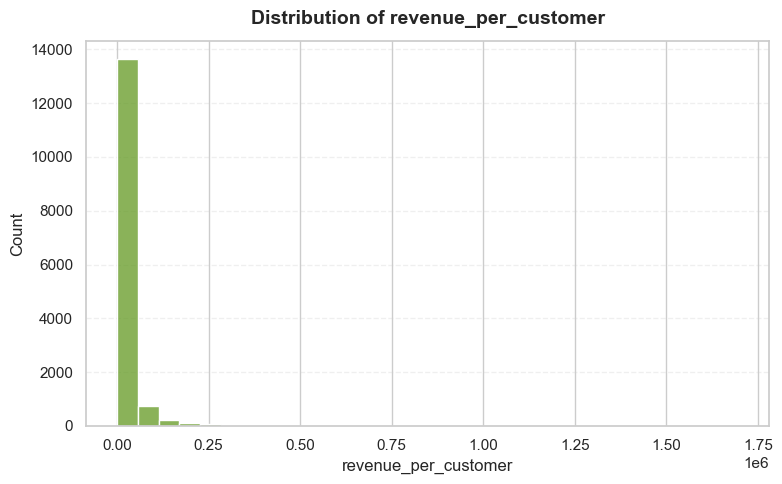

In [41]:
col = "revenue_per_customer"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    color="#639922",
    line_kws={"color": "#993556", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `revenue_per_customer` is highly concentrated at lower values, with the vast majority of companies generating relatively modest revenue from each customer. Only a small number of companies achieve exceptionally high revenue per customer, creating a long right tail in the distribution.
* This pattern suggests that most businesses operate within a similar customer-value range, while a few organizations generate substantially greater revenue from each customer. Such differences may arise from premium products, specialized services, high-value customer segments, or unique business models.
* The extreme imbalance visible in the histogram indicates that this feature contains several unusually large observations. These values contribute to the high skewness and variability observed in the statistical summary and may have a strong influence on analytical results. Therefore, this feature should be examined carefully during subsequent analysis and model development to ensure that a small number of extreme cases do not dominate the findings.

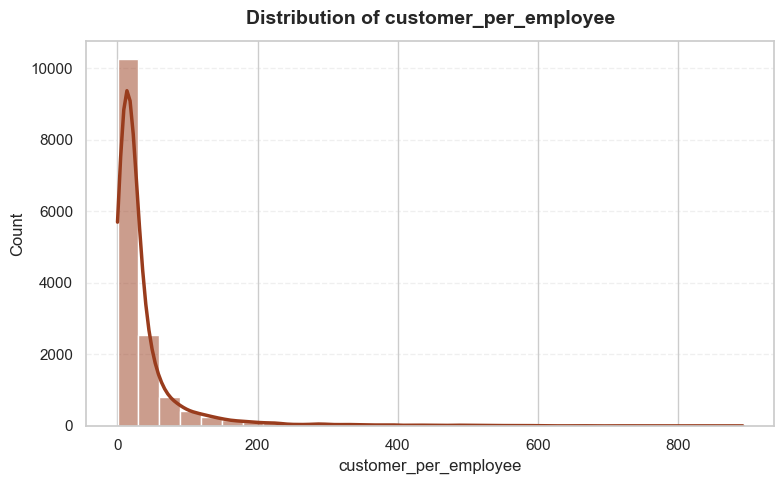

In [42]:
col = "customer_per_employee"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#993C1D",
    line_kws={"color": "#0F6E56", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `customer_per_employee` is strongly right-skewed, with most companies clustered at lower values and a relatively small number of companies extending far into the upper range. This indicates that the typical company serves a moderate number of customers per employee, while a few organizations manage significantly larger customer bases with comparatively smaller workforces.
* The long right tail suggests substantial differences in operating models across companies. Some businesses appear to rely on highly scalable processes that allow each employee to serve many customers, whereas others require more employee involvement for customer support, service delivery, or operations.
* This wide variation highlights that workforce utilization differs considerably across the dataset. As a result, customer_per_employee may provide useful insight into operational efficiency and business scalability. However, the presence of extreme values should be considered during later analysis, as a small number of observations may have a disproportionate influence on summary statistics and model behavior.

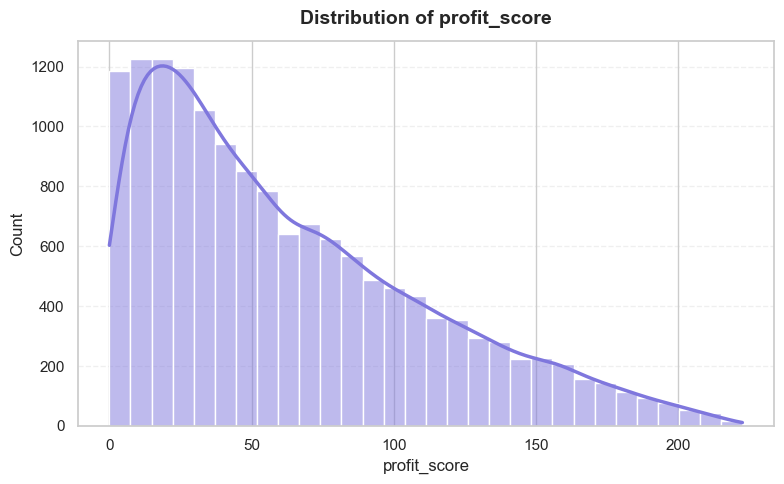

In [43]:
col = "profit_score"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#7F77DD",
    line_kws={"color": "#BA7517", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `profit_score` shows that lower and moderate values are much more common than very high values. Most companies are concentrated in the lower portion of the distribution, while the number of companies gradually decreases as the profit score increases.
* This pattern indicates that achieving simultaneously strong profitability and high market ratings is less common within the dataset. Only a relatively small group of companies attain very high profit scores, suggesting that exceptional financial performance combined with strong market perception is difficult to achieve.
* Unlike some of the other engineered features that contain extreme outliers, the decline in this distribution is more gradual and smooth. This suggests that profit_score captures meaningful differences in company performance while remaining relatively stable and interpretable. As a combined measure of profitability and market perception, it provides a useful way to distinguish stronger-performing companies from the broader population.

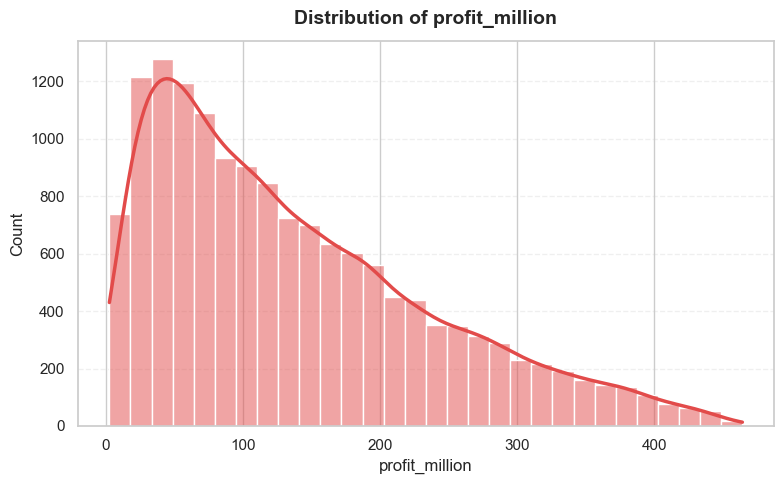

In [44]:
col = "profit_million"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    kde=True,
    color="#E24B4A",
    line_kws={"color": "#085041", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The distribution of `profit_million` is concentrated toward lower and moderate profit values, with the number of companies gradually decreasing as profit increases. While many companies generate profits within a relatively common range, only a smaller group achieves exceptionally high profit levels.
* This pattern suggests that strong profitability is achieved by a limited portion of companies in the dataset. As profits grow larger, companies become progressively less common, creating the long right tail visible in the distribution. Such a trend is typical in business data, where a small number of organizations often account for the highest levels of financial performance.
* The smooth decline in the histogram indicates that profit values are spread across multiple levels rather than being clustered into a few specific ranges. This variation is useful for analysis because it allows comparisons between companies with different levels of financial success and helps identify factors that may be associated with higher profitability.

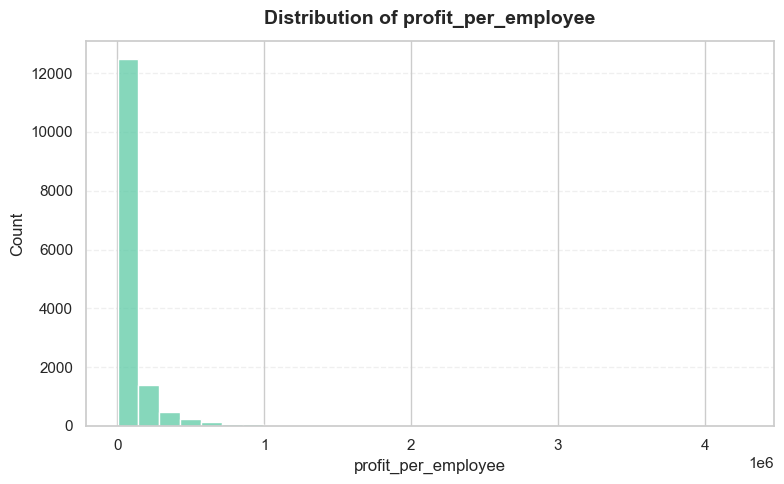

In [45]:
col = "profit_per_employee"
plt.figure(figsize=(8, 5))
sns.histplot(
    df[col],
    bins=30,
    color="#5DCAA5",
    line_kws={"color": "#993556", "linewidth": 2.5}
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* Among all the engineered features, `profit_per_employee` exhibits one of the most extreme distributions. The histogram shows that the vast majority of companies are concentrated near the lower end of the scale, while a very small number of companies achieve exceptionally high profit generated per employee.
* This pattern suggests that workforce profitability varies substantially across organizations. Most companies generate similar levels of profit per employee, but a small group appears to operate with significantly greater efficiency, allowing each employee to contribute much more profit to the business.
* The long right tail indicates the presence of a few unusually large values that have a strong impact on the overall distribution. These observations may represent highly profitable companies, organizations with lean workforces, or business models that generate substantial profit without requiring large numbers of employees.
* The distribution highlights that profit generation is not evenly spread across the workforce of all companies. As a result, this feature may provide valuable insight into operational efficiency, but its extreme values should be considered carefully when interpreting results or building predictive models.

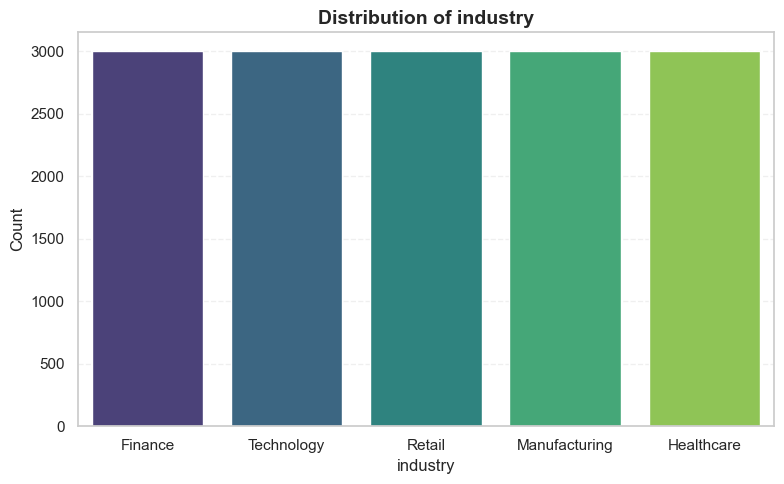

In [46]:
col = "industry"

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=col,
    palette="viridis"
)

plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold")
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=0)  # straight labels

plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The industry distribution is perfectly balanced across the five sectors included in the dataset: **Finance, Technology, Retail, Manufacturing, and Healthcare**. Each industry contains the same number of companies, ensuring that no single sector dominates the analysis.
* This balanced representation is beneficial because it reduces the risk of industry-specific bias influencing the results. Any patterns observed during exploratory analysis or model development are therefore less likely to be driven by an overrepresentation of a particular sector.
* Having equal coverage across industries also makes comparisons more meaningful. It allows business characteristics such as revenue, profitability, customer reach, and market ratings to be examined fairly across different sectors, providing a broader understanding of company performance within the dataset.

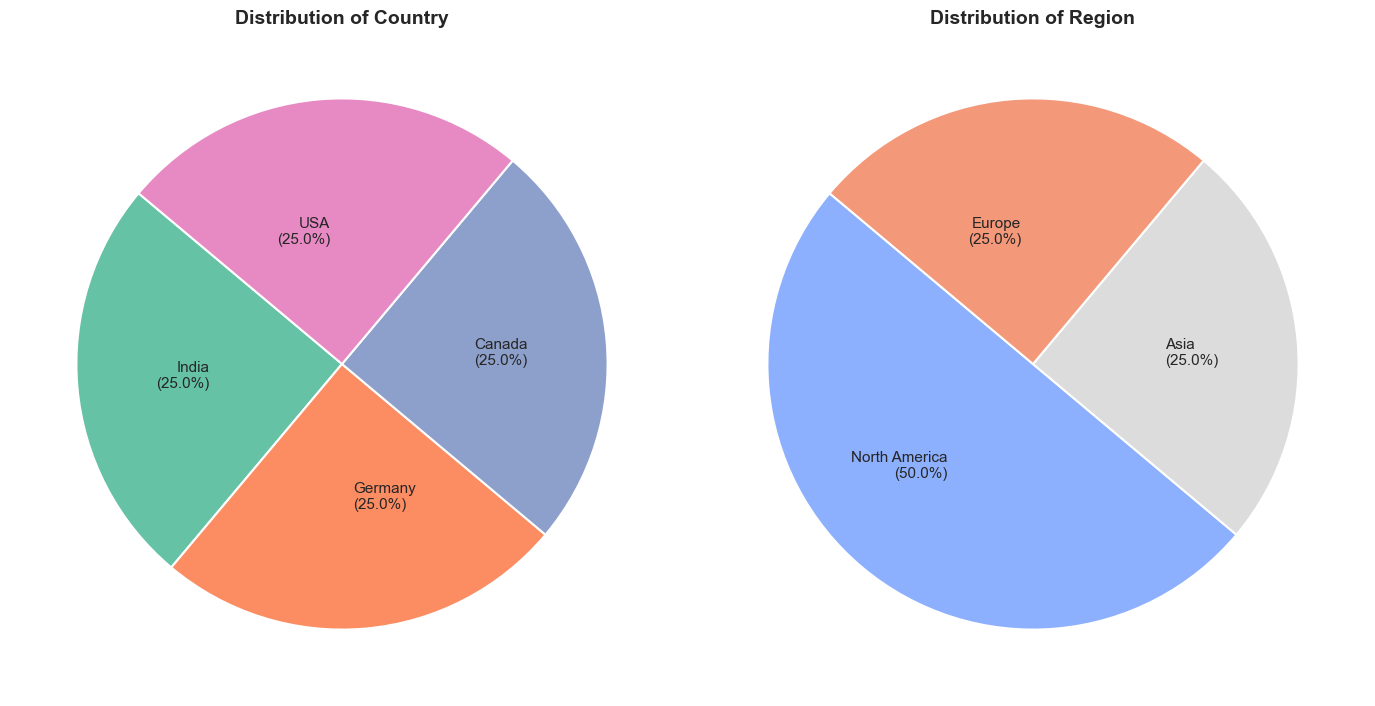

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

country_counts = df["country"].value_counts()

axes[0].pie(
    country_counts,
    labels=[
        f"{country}\n({pct:.1f}%)"
        for country, pct in zip(
            country_counts.index,
            country_counts.values / country_counts.sum() * 100
        )
    ],
    colors=sns.color_palette("Set2", len(country_counts)),
    startangle=140,
    labeldistance=0.5,  # move labels inside
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

axes[0].set_title(
    "Distribution of Country",
    fontsize=14,
    fontweight="bold"
)

region_counts = df["region"].value_counts()

axes[1].pie(
    region_counts,
    labels=[
        f"{region}\n({pct:.1f}%)"
        for region, pct in zip(
            region_counts.index,
            region_counts.values / region_counts.sum() * 100
        )
    ],
    colors=sns.color_palette("coolwarm", len(region_counts)),
    startangle=140,
    labeldistance=0.5,  # move labels inside
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

axes[1].set_title(
    "Distribution of Region",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

* The country distribution shows an equal representation of companies from India, Germany, Canada, and the USA, with each country contributing 25% of the observations. This balanced structure ensures that no single country has a disproportionate influence on the analysis.
* At the regional level, North America accounts for half of the dataset, while Asia and Europe each represent one-quarter of the observations. This distribution reflects the mapping of countries to regions, with both the USA and Canada belonging to North America.
* The geographical coverage provided by these countries and regions creates a useful foundation for comparing business characteristics across different markets. Since the dataset contains companies from multiple locations, subsequent analyses can explore whether revenue, profitability, customer reach, and market ratings vary across geographic segments.

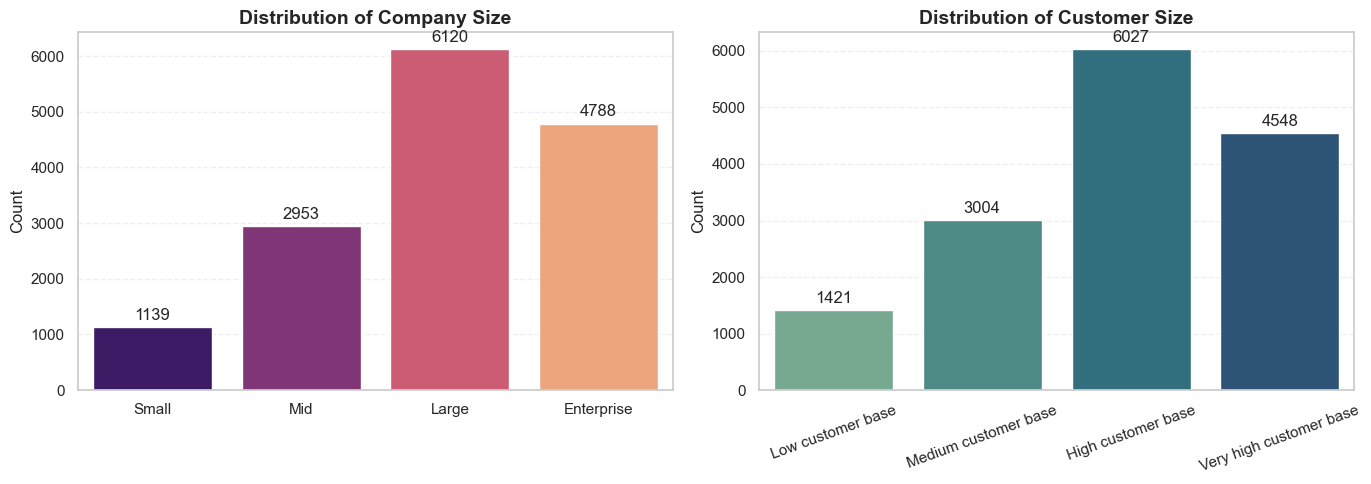

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="company_size",
    order=["Small", "Mid", "Large", "Enterprise"],
    palette="magma",
    ax=axes[0]
)

axes[0].set_title("Distribution of Company Size",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

sns.countplot(
    data=df,
    x="customer_size",
    order=[
        "Low customer base",
        "Medium customer base",
        "High customer base",
        "Very high customer base"
    ],
    palette="crest",
    ax=axes[1]
)

axes[1].set_title("Distribution of Customer Size",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

* The distributions of company size and customer size reveal that the dataset is primarily composed of larger organizations with substantial customer bases. Large and Enterprise companies account for the majority of observations, while Small companies represent only a limited portion of the dataset.
* A similar pattern is observed for customer size. Companies with High and Very High customer bases are considerably more common than those with Low customer bases. This indicates that the dataset contains a strong representation of businesses operating at scale.
* Together, these distributions suggest that many companies in the dataset have established operations, sizeable workforces, and broad customer reach. This characteristic should be considered when interpreting analytical results, as the findings may be more representative of larger organizations than small businesses.

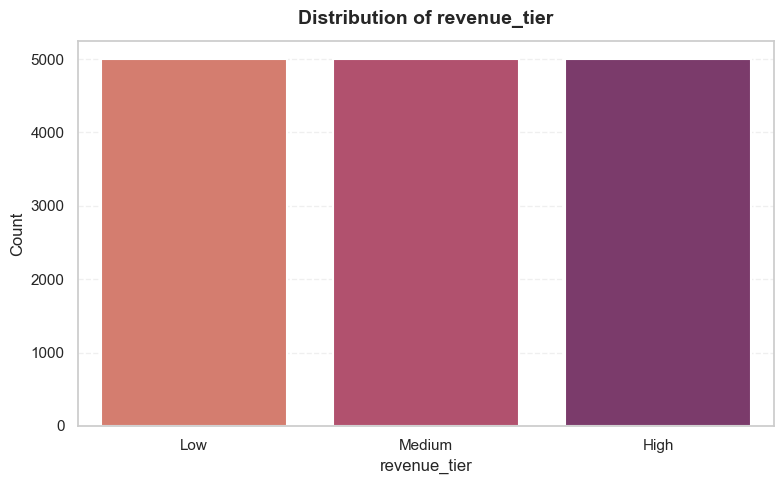

In [49]:
col = "revenue_tier"
plt.figure(figsize=(8, 5))
revenue_counts = df[col].value_counts()
sns.barplot(
    x=revenue_counts.index,
    y=revenue_counts.values,
    palette="flare",
    edgecolor="white",
    linewidth=1.5
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The `revenue tier` distribution is perfectly balanced across the three categories: Low, Medium, and High. Each tier contains exactly one-third of the observations, resulting in an equal number of companies within each revenue group.
* This balanced structure is expected because the revenue tiers were created using quantile-based binning, which divides the data into groups containing similar numbers of observations. As a result, each category represents a different segment of the revenue distribution while maintaining equal sample sizes.
* Creating these tiers provides a simplified view of company revenue levels and can be useful for comparing business characteristics across lower, medium, and higher revenue organizations. The balanced distribution also ensures that analyses involving revenue tiers are not affected by class imbalance, allowing comparisons between groups to be made more fairly.

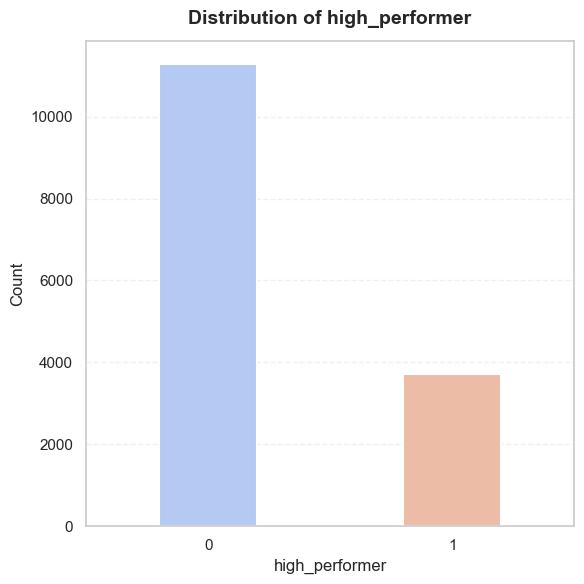

In [50]:
col = "high_performer"
plt.figure(figsize=(6, 6))
hp_counts = df[col].value_counts()
sns.barplot(
    x=hp_counts.index,
    y=hp_counts.values,
    palette="coolwarm",
    edgecolor="white",
    linewidth=1.5,
    width=0.4
)
plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold", pad=12)
plt.xlabel(col, fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The `high_performer` feature shows a clear imbalance between the two groups. Most companies fall into the non-high-performer category, while a smaller proportion meet the criteria required to be classified as high performers.
* This outcome is expected because a company must simultaneously achieve both an above-median profit margin and an above-median market rating to receive a value of 1. By combining these two conditions, the feature identifies organizations that perform well across multiple dimensions rather than excelling in only one area.
* The distribution suggests that strong profitability alone is not sufficient for a company to be considered a high performer in this framework. Likewise, a strong market rating without above-average profitability does not qualify. As a result, the feature provides a more selective measure of business performance and highlights companies that demonstrate strength in both financial results and market perception.
* The presence of both groups in meaningful numbers makes this feature useful for comparative analysis. It allows future exploration of whether high-performing companies differ from other organizations in terms of revenue, customer reach, company size, or operational efficiency.

## 7. Outlier detection

### 7.1 IQR method

In [51]:
numeric_original = [
    "employee_count",
    "annual_revenue_million",
    "profit_margin_percent",
    "customer_count",
    "market_rating",
    "founded_year",
    "company_age"
]

In [52]:
print("IQR Outlier Detection Results:")
print(f"{'Feature':<35} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("─" * 110)

iqr_records = []
for col in numeric_original:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    pct    = n_out / len(df) * 100
    iqr_records.append({"Feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                         "Lower Fence": lo, "Upper Fence": hi,
                         "Outliers": n_out, "Outlier %": round(pct, 3)})
    print(f"  {col:<33} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lo:>10.2f} {hi:>10.2f} {n_out:>10d} {pct:>6.2f}%")

iqr_df = pd.DataFrame(iqr_records)

IQR Outlier Detection Results:
Feature                                     Q1         Q3        IQR      Lower      Upper   Outliers      %
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  employee_count                       1379.00    3839.00    2460.00   -2311.00    7529.00          0   0.00%
  annual_revenue_million                299.92     797.57     497.66    -446.57    1544.05          0   0.00%
  profit_margin_percent                  15.05      35.10      20.05     -15.03      65.18          0   0.00%
  customer_count                      25676.25   75271.25   49595.00  -48716.25  149663.75          0   0.00%
  market_rating                           1.20       3.80       2.60      -2.70       7.70          0   0.00%
  founded_year                         1997.00    2012.00      15.00    1974.50    2034.50          0   0.00%
  company_age                            14.00      29.00      15.00      -8.50      51.5

* The IQR-based outlier analysis identified no outliers in any of the original numerical variables, including employee count, annual revenue, profit margin, customer count, market rating, founded year, and company age.
* For each feature, all observations fall within the calculated lower and upper IQR boundaries, resulting in an outlier percentage of 0%. This indicates that the original dataset is highly consistent and does not contain unusually extreme values that could distort summary statistics or model performance.
* The absence of outliers suggests that the numerical variables were generated within controlled ranges and exhibit stable distributions. As a result, no outlier treatment is required at this stage of the analysis, allowing subsequent feature engineering and modeling steps to proceed without the need for data trimming, winsorization, or outlier removal.

### 7.2 Z-score method

In [53]:
from scipy import stats
print("Z-Score Outlier Detection:")
print(f"{'Feature':<35} {'Outliers':>10} {'%':>8}")
print("─" * 60)

zscore_records = []
for col in numeric_original:
    z     = np.abs(stats.zscore(df[col].dropna()))
    n_out = (z > 3).sum()
    pct   = n_out / len(df) * 100
    zscore_records.append({"Feature": col, "Outliers (Z>3)": n_out, "%": round(pct, 3)})
    print(f"  {col:<33} {n_out:>10d} {pct:>8.3f}%")

Z-Score Outlier Detection:
Feature                               Outliers        %
────────────────────────────────────────────────────────────
  employee_count                             0    0.000%
  annual_revenue_million                     0    0.000%
  profit_margin_percent                      0    0.000%
  customer_count                             0    0.000%
  market_rating                              0    0.000%
  founded_year                               0    0.000%
  company_age                                0    0.000%


* The Z-score analysis confirms that all original numerical features fall within three standard deviations of their respective means. No observations were identified as statistically unusual under the Z-score threshold of ±3.
* This result indicates that the numerical variables are tightly controlled around their central values, with no extreme observations standing far away from the rest of the data. The consistency between different ranges of each variable suggests a stable dataset with predictable patterns across the original business metrics.
* Since both the central tendency and spread remain well-behaved across all original numerical features, subsequent analysis can focus on understanding relationships between variables rather than addressing extreme observations. Any unusual behavior observed later is therefore more likely to originate from engineered features rather than from the original data itself.

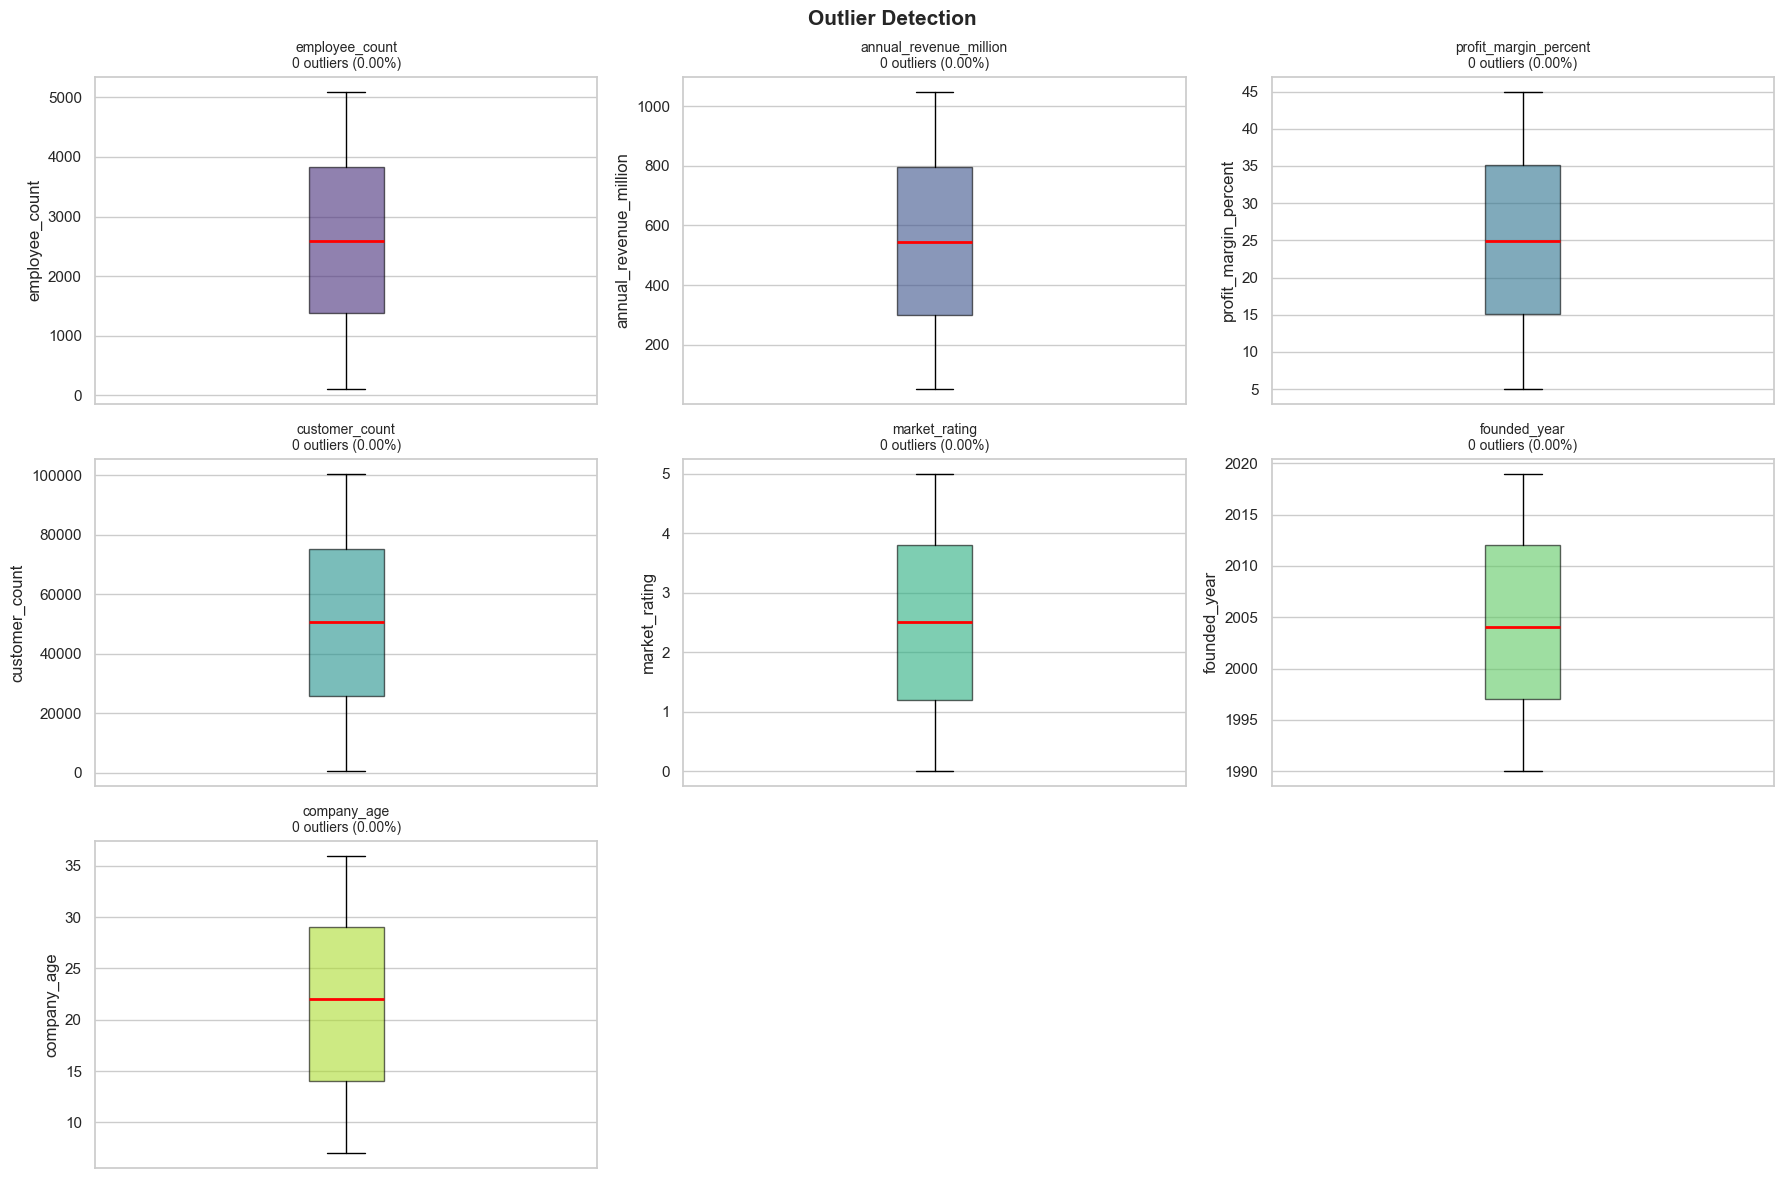

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

fig.suptitle(
    "Outlier Detection",
    fontsize=15,
    fontweight="bold"
)

axes = axes.flatten()

PALETTE = sns.color_palette(
    "viridis",
    len(numeric_original)
)

for i, col in enumerate(numeric_original):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    is_out = (
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    )

    ax = axes[i]

    ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(
            facecolor=PALETTE[i],
            alpha=0.6
        ),
        medianprops=dict(
            color="red",
            lw=2
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="#E76F51",
            markersize=4,
            alpha=0.6
        )
    )

    ax.set_title(
        f"{col}\n{is_out.sum()} outliers ({is_out.mean()*100:.2f}%)",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_ylabel(col)

for j in range(len(numeric_original), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* The boxplots provide a visual summary of the distribution, spread, and central tendency of the original numerical features. Across all variables, the median values are positioned near the center of their respective boxes, indicating relatively balanced distributions without strong asymmetry.
* The interquartile ranges show that observations are distributed across a broad portion of each variable's range rather than being concentrated around a narrow set of values. This pattern is consistent across employee count, annual revenue, customer count, market rating, founded year, and company age.
* The whiskers extend smoothly toward the minimum and maximum values without isolated observations beyond the expected boundaries. Overall, the boxplots suggest that the original business metrics exhibit stable variation while maintaining consistent distributional characteristics across the dataset.

## 8. Bivariate analysis

,company_name,annual_revenue_million
860,FinTrust_861,1049.96
6293,BuildWorks_6294,1049.96
11910,FinTrust_11911,1049.93
8216,TechNova_8217,1049.91
12907,RetailHub_12908,1049.87
47,RetailHub_48,1049.84
14669,MediCorp_14670,1049.71
7616,TechNova_7617,1049.62
1662,RetailHub_1663,1049.59
444,MediCorp_445,1049.57


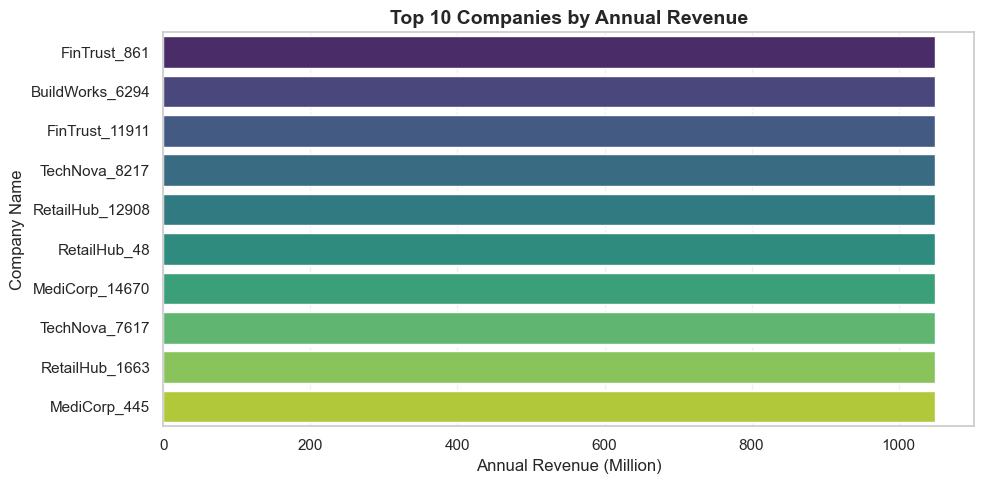

In [55]:
top_companies = (
    df[["company_name", "annual_revenue_million"]]
    .sort_values("annual_revenue_million", ascending=False)
    .head(10)
)

display(top_companies)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_companies,
    x="annual_revenue_million",
    y="company_name",
    palette="viridis"
)

plt.title("Top 10 Companies by Annual Revenue",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Annual Revenue (Million)")
plt.ylabel("Company Name")

plt.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

* The top 10 companies by annual revenue exhibit very similar revenue levels, with all values clustered around 1,050 million. The small difference between the highest- and tenth-ranked companies indicates that no single organization substantially outperforms the others in terms of revenue.
* The ranking also includes companies from multiple industries, suggesting that high-revenue companies are distributed across different sectors rather than concentrated within a specific industry. Overall, the results indicate a relatively even distribution of top-performing companies within the dataset.

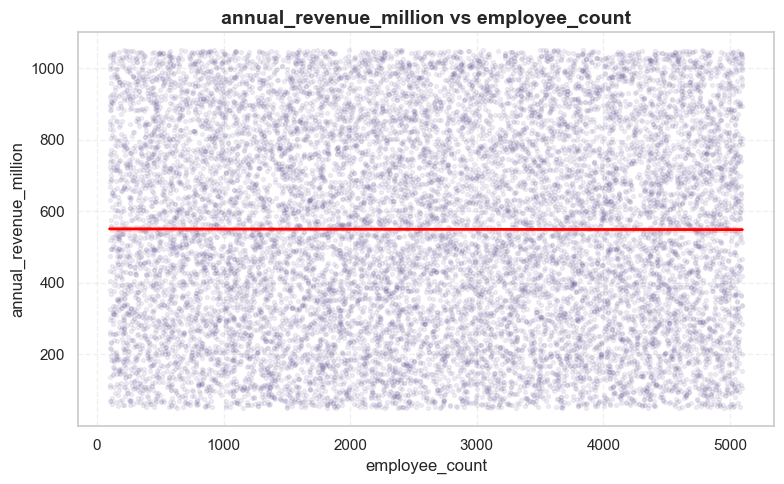

In [56]:
x = "employee_count"
y = "annual_revenue_million"

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={
        "alpha": 0.08,
        "s": 8
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title(
    f"{y} vs {x}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(x)
plt.ylabel(y)

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The scatter plot reveals no clear relationship between employee count and annual revenue. Companies with small workforces and companies with large workforces are observed across the entire revenue range, indicating that revenue does not systematically increase or decrease with the number of employees.
* The nearly horizontal trend line further supports the absence of a meaningful linear pattern between these two variables. This observation is consistent with the correlation analysis, which reported a coefficient close to zero.
* From a business perspective, the results suggest that workforce size alone is not a reliable indicator of company revenue within this dataset. Other factors are likely to play a more important role in explaining revenue differences across companies.

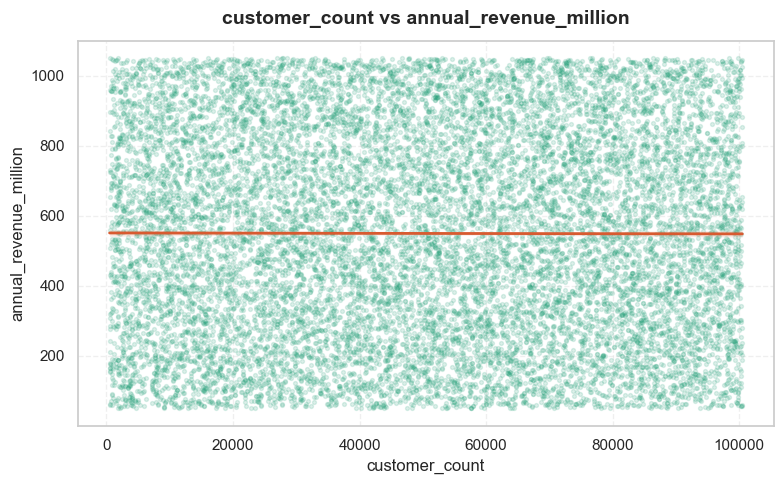

In [57]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="customer_count",
    y="annual_revenue_million",
    scatter_kws={"alpha": 0.15, "s": 8, "color": "#1D9E75"},
    line_kws={"color": "#D85A30", "linewidth": 2}
)
plt.title("customer_count vs annual_revenue_million", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("customer_count", fontsize=12)
plt.ylabel("annual_revenue_million", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The scatter plot shows no meaningful relationship between customer count and annual revenue. Companies with both small and large customer bases are observed across the full range of revenue values, indicating that revenue does not consistently increase as the number of customers grows.
* The fitted regression line remains nearly horizontal throughout the plot, suggesting that changes in customer count have little influence on revenue within this dataset. This visual observation aligns with the correlation analysis, which indicated an almost zero linear relationship between the two variables.
* These results imply that customer volume alone is not sufficient to explain revenue differences among companies. Organizations with similar customer counts may generate substantially different revenue levels, suggesting that other business characteristics play a more significant role in determining financial performance.

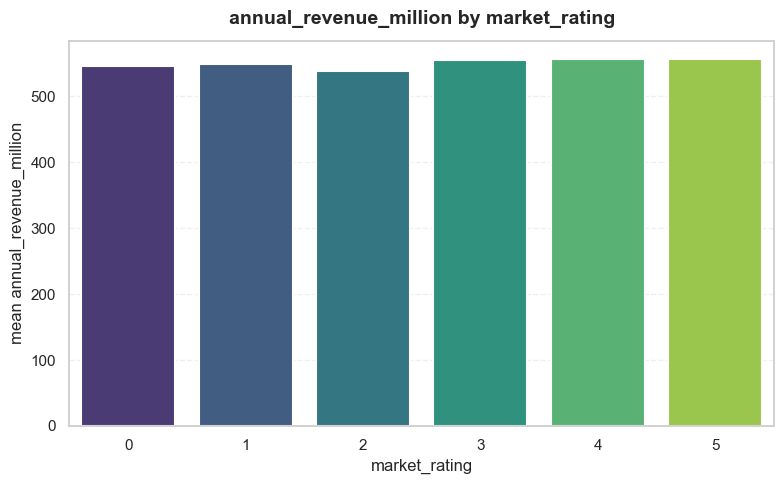

In [58]:
plt.figure(figsize=(8, 5))
df["market_rating_rounded"] = df["market_rating"].round(0).astype(int)
sns.barplot(
    data=df,
    x="market_rating_rounded",
    y="annual_revenue_million",
    estimator="mean",
    palette="viridis",
    edgecolor="white",
    linewidth=1.5,
    errorbar=None
)
plt.title("annual_revenue_million by market_rating", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("market_rating", fontsize=12)
plt.ylabel("mean annual_revenue_million", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The average annual revenue remains relatively stable across all market rating categories. Although companies with higher ratings show slightly greater average revenue, the differences between rating groups are small and do not indicate a strong upward trend.
* This suggests that market rating alone has limited influence on revenue within the dataset. Companies with lower ratings and companies with higher ratings generate broadly similar levels of revenue on average.
* The visual pattern is consistent with the correlation analysis, which identified only a very weak positive relationship between market rating and annual revenue. While market perception may contribute to business performance, it does not appear to be a major driver of revenue differences in this dataset.

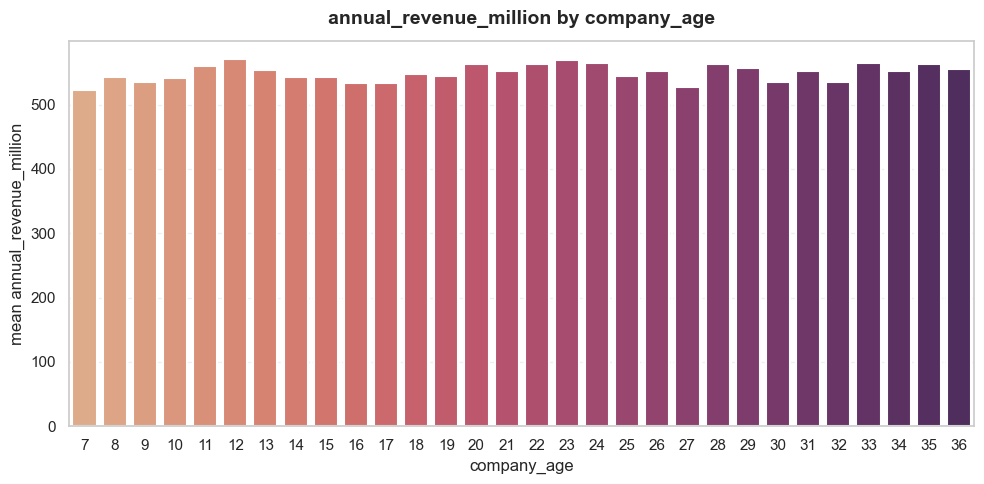

In [59]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="company_age",
    y="annual_revenue_million",
    estimator="mean",
    palette="flare",
    edgecolor="white",
    linewidth=1.5,
    errorbar=None
)
plt.title("annual_revenue_million by company_age", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("company_age", fontsize=12)
plt.ylabel("mean annual_revenue_million", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The average annual revenue remains relatively consistent across companies of different ages. While some age groups exhibit slightly higher or lower average revenue, the differences are modest and do not follow a clear trend.
* This suggests that company age alone is not a strong indicator of revenue performance within the dataset. Both younger and older organizations appear capable of generating similar levels of revenue, indicating that business maturity does not necessarily translate into higher earnings.
* The visual pattern supports the earlier correlation analysis, which identified only a very weak relationship between company age and annual revenue. Overall, the results indicate that factors other than age are likely to play a more important role in explaining revenue variation among companies.

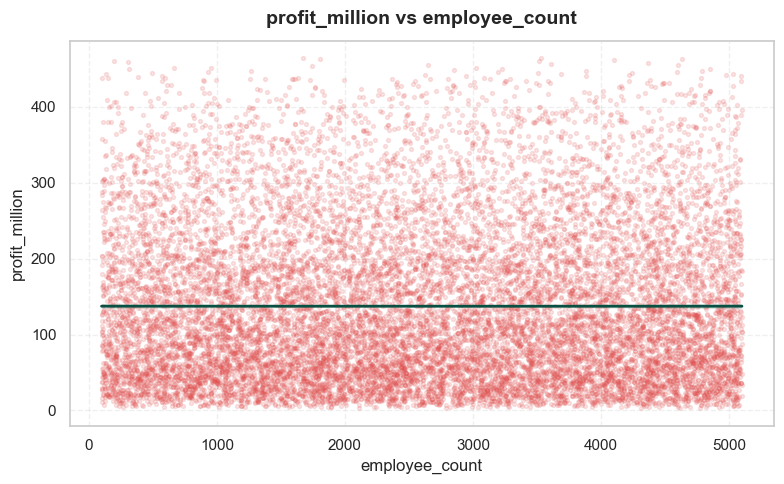

In [60]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="employee_count",
    y="profit_million",
    scatter_kws={"alpha": 0.15, "s": 8, "color": "#E24B4A"},
    line_kws={"color": "#085041", "linewidth": 2}
)
plt.title("profit_million vs employee_count", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("employee_count", fontsize=12)
plt.ylabel("profit_million", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* The scatter plot indicates no clear relationship between employee count and profit generated by a company. Organizations with both small and large workforces are distributed across the full range of profit values, suggesting that profit levels do not systematically change as employee count increases.
* The fitted regression line remains nearly horizontal, indicating the absence of a meaningful linear association between the two variables. This suggests that workforce size alone is not a strong determinant of company profitability within the dataset.
* The results imply that companies can achieve similar profit levels regardless of the number of employees they maintain. Therefore, factors such as operational efficiency, profit margins, customer value, and business strategy may be more important in explaining differences in profit than workforce size alone.

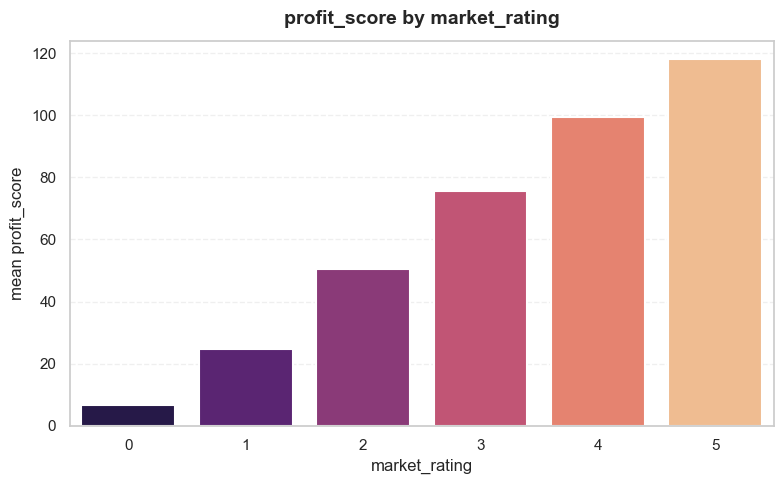

In [61]:
plt.figure(figsize=(8, 5))
df["market_rating_rounded"] = df["market_rating"].round(0).astype(int)
sns.barplot(
    data=df,
    x="market_rating_rounded",
    y="profit_score",
    estimator="mean",
    palette="magma",
    edgecolor="white",
    linewidth=1.5,
    errorbar=None
)
plt.title("profit_score by market_rating", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("market_rating", fontsize=12)
plt.ylabel("mean profit_score", fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* A strong positive trend can be observed between market rating and profit score. The average profit score increases consistently across each market rating category, with the highest-rated companies achieving the largest scores.
* This pattern indicates that companies receiving stronger market ratings tend to combine favorable market perception with higher profitability levels. As a result, their overall profit score is substantially greater than that of lower-rated organizations.
* The steady upward progression of the bars suggests that market rating plays an important role in differentiating companies when profit score is considered. Among all rating groups, companies with ratings of 4 and 5 demonstrate the strongest overall performance according to this metric.

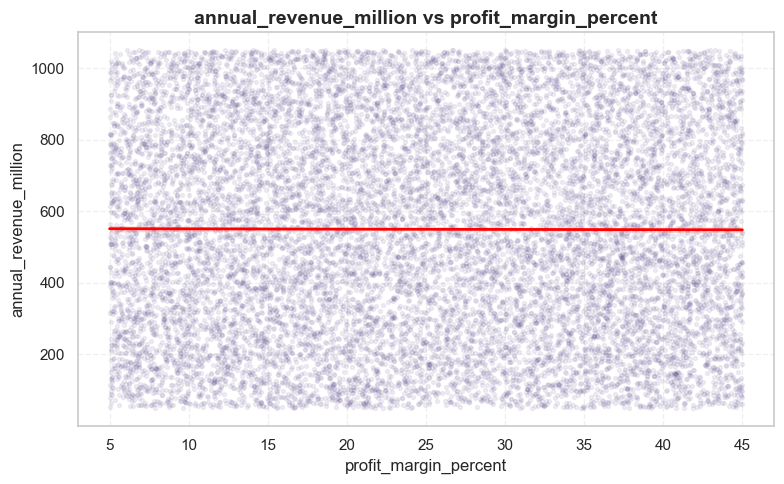

In [62]:
x = "profit_margin_percent"  
y = "annual_revenue_million"

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={
        "alpha": 0.08,
        "s": 8
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title(
    f"{y} vs {x}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(x)
plt.ylabel(y)

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* Although profit margin varies from 5% to 45%, companies across this entire range generate similar levels of revenue. Some companies with lower profit margins achieve very high revenue, while others with higher margins generate average or even lower revenue. This suggests that making sales and earning profit efficiently are two different aspects of business performance. In this dataset, a company's revenue does not appear to depend on its profit margin, as no consistent trend can be observed between the two variables.

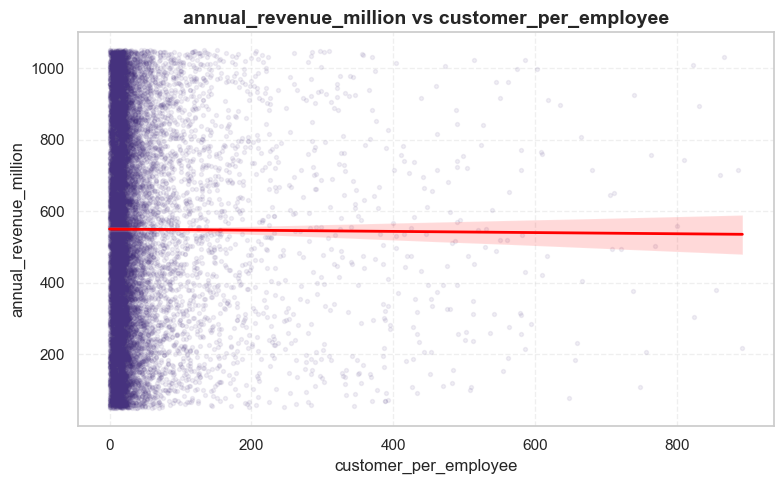

In [63]:
x = "customer_per_employee"
y = "annual_revenue_million"

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={
        "alpha": 0.08,
        "s": 8
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title(f"{y} vs {x}", fontsize=14, fontweight="bold")

plt.xlabel(x)
plt.ylabel(y)

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

* Most companies are concentrated in the lower range of customers per employee, while only a small number operate with very high customer-to-employee ratios. Despite this variation, annual revenue remains widely spread across all levels of customer_per_employee. Companies serving many customers per employee do not consistently generate higher revenue than those serving fewer customers per employee.
* This suggests that simply increasing the number of customers handled by each employee does not guarantee greater revenue. Other business factors, such as pricing, product value, industry characteristics, and operational strategy, are likely to have a stronger influence on revenue performance than customer workload alone.

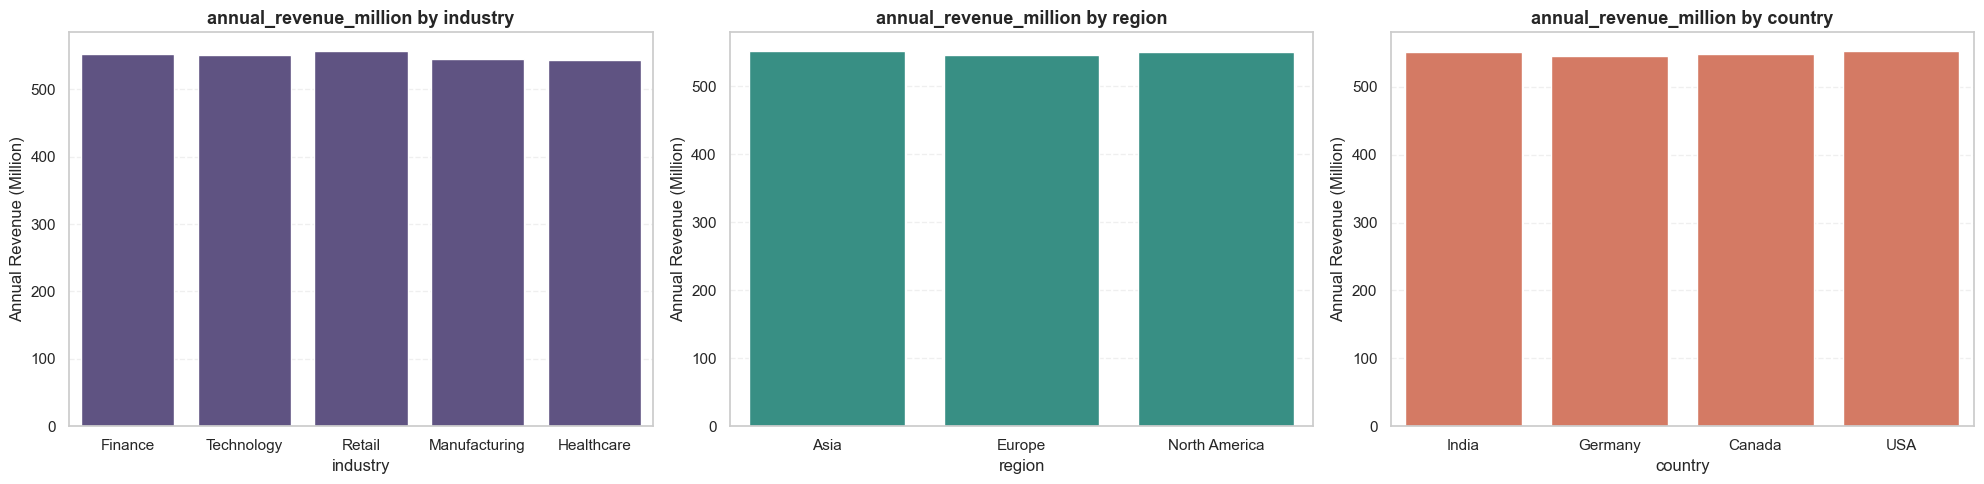

In [64]:
cols = ["industry", "region", "country"]
y = "annual_revenue_million"

colors = ["#5B4B8A", "#2A9D8F", "#E76F51"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(cols):

    sns.barplot(
        data=df,
        x=col,
        y=y,
        errorbar=None,
        color=colors[i],
        ax=axes[i]
    )

    axes[i].set_title(f"{y} by {col}", fontsize=13, fontweight="bold")

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Annual Revenue (Million)")
    axes[i].grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

* The average annual revenue remains remarkably consistent across industries, regions, and countries. No category demonstrates a substantial advantage over the others, as the mean revenue values are clustered within a narrow range.
* This suggests that revenue generation is not concentrated in a specific sector or geographic location. Instead, companies from different industries and regions contribute similarly to the overall revenue distribution, indicating a balanced dataset with no dominant group.

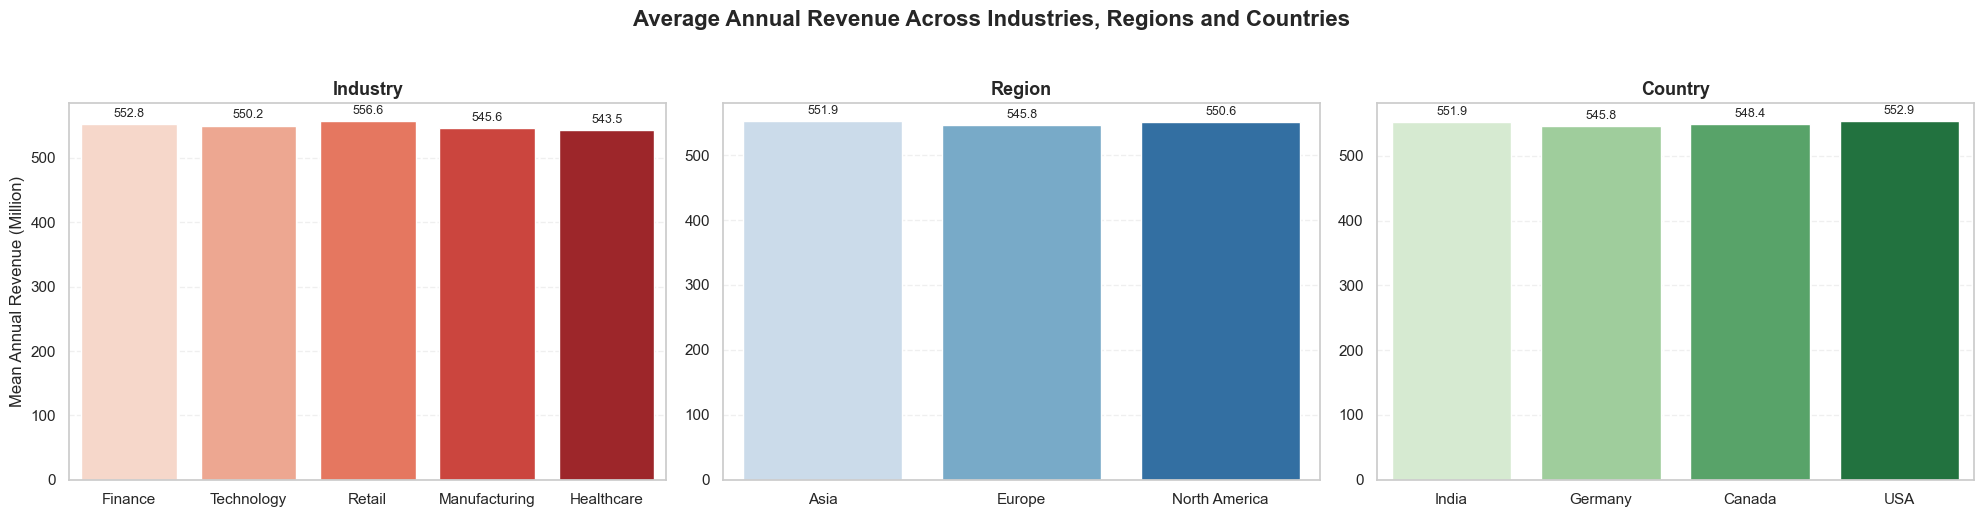

In [65]:
cols = ["industry", "region", "country"]
y = "annual_revenue_million"

palettes = ["Reds", "Blues", "Greens"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(cols):

    sns.barplot(
        data=df,
        x=col,
        y=y,
        errorbar=None,
        palette=palettes[i],
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=13,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    
    if i == 0:
        axes[i].set_ylabel("Mean Annual Revenue (Million)")
    else:
        axes[i].set_ylabel("")

    axes[i].grid(
        axis="y",
        alpha=0.3,
        linestyle="--"
    )

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.1f", fontsize=9, padding=3)

plt.suptitle(
    "Average Annual Revenue Across Industries, Regions and Countries",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

* The average annual revenue remains highly consistent across industries, regions, and countries. Although minor differences exist between categories, the gap between the highest and lowest averages is relatively small. Retail companies show the highest average revenue among industries, North America leads slightly among regions, and the USA records the highest average among countries. However, the overall similarity of the values suggests that revenue is distributed fairly evenly throughout the dataset rather than being concentrated within a particular sector or geographic location.

## 9. Multivariate analysis

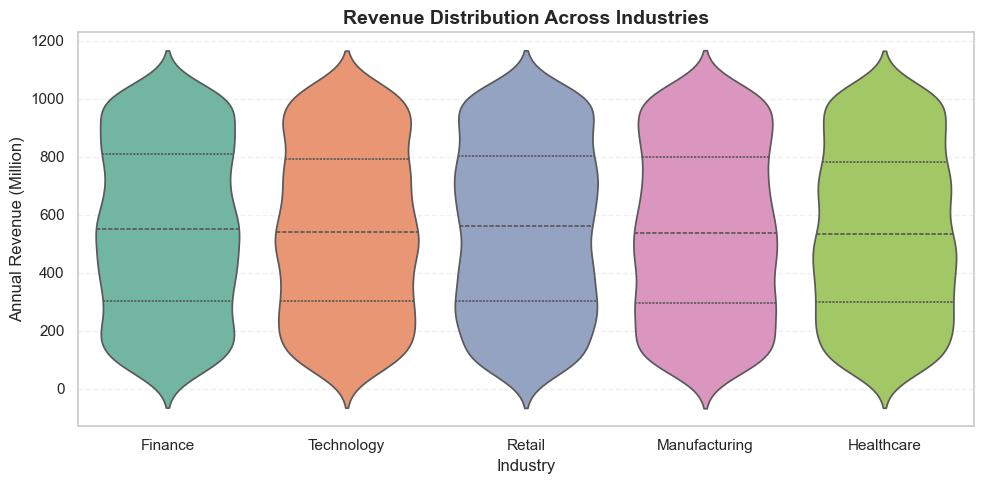

In [66]:
plt.figure(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="industry",
    y="annual_revenue_million",
    palette="Set2",
    inner="quartile"
)

plt.title("Revenue Distribution Across Industries", fontsize=14, fontweight="bold")

plt.xlabel("Industry", fontsize=12)
plt.ylabel("Annual Revenue (Million)", fontsize=12)

plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

* The revenue distributions across all industries are remarkably similar. Each industry exhibits a comparable spread of revenue values, with median revenue levels appearing nearly identical. The shape of the distributions also remains consistent, indicating that no industry dominates in terms of revenue generation.
* This suggests that industry type does not have a substantial influence on annual revenue within the dataset. Companies from Finance, Technology, Retail, Manufacturing, and Healthcare display very similar revenue patterns, reinforcing the earlier findings that revenue is distributed evenly across the major business sectors.

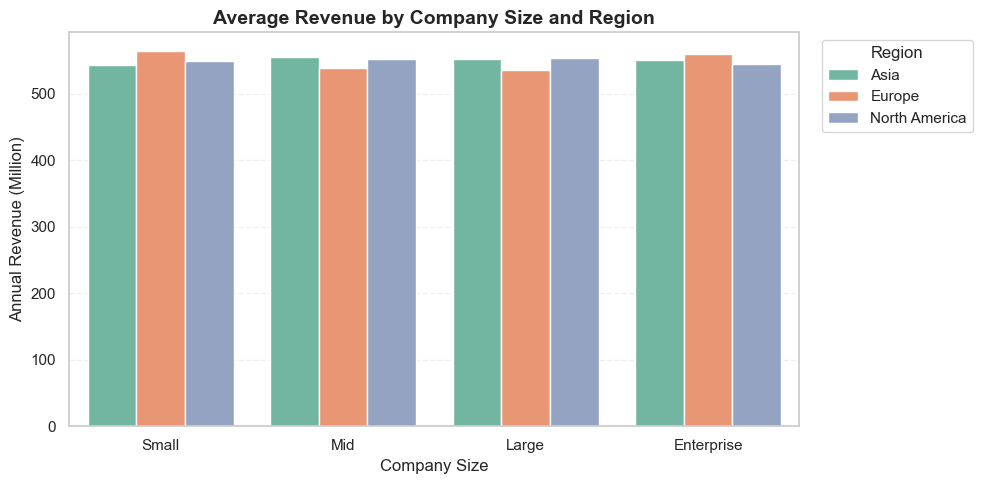

In [67]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="company_size",
    y="annual_revenue_million",
    hue="region",
    palette="Set2",
    errorbar=None
)

plt.title(
    "Average Revenue by Company Size and Region",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Company Size")
plt.ylabel("Annual Revenue (Million)")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

* The chart shows that average revenue stays fairly consistent regardless of company size or region. Small companies generate revenue levels that are surprisingly close to those of Enterprise companies, suggesting that having a larger workforce does not automatically translate into higher revenue. A similar pattern appears across regions, where Asia, Europe, and North America all maintain comparable revenue figures. Overall, revenue seems to be spread quite evenly throughout the dataset, with no specific region or company-size category standing out as a clear leader.

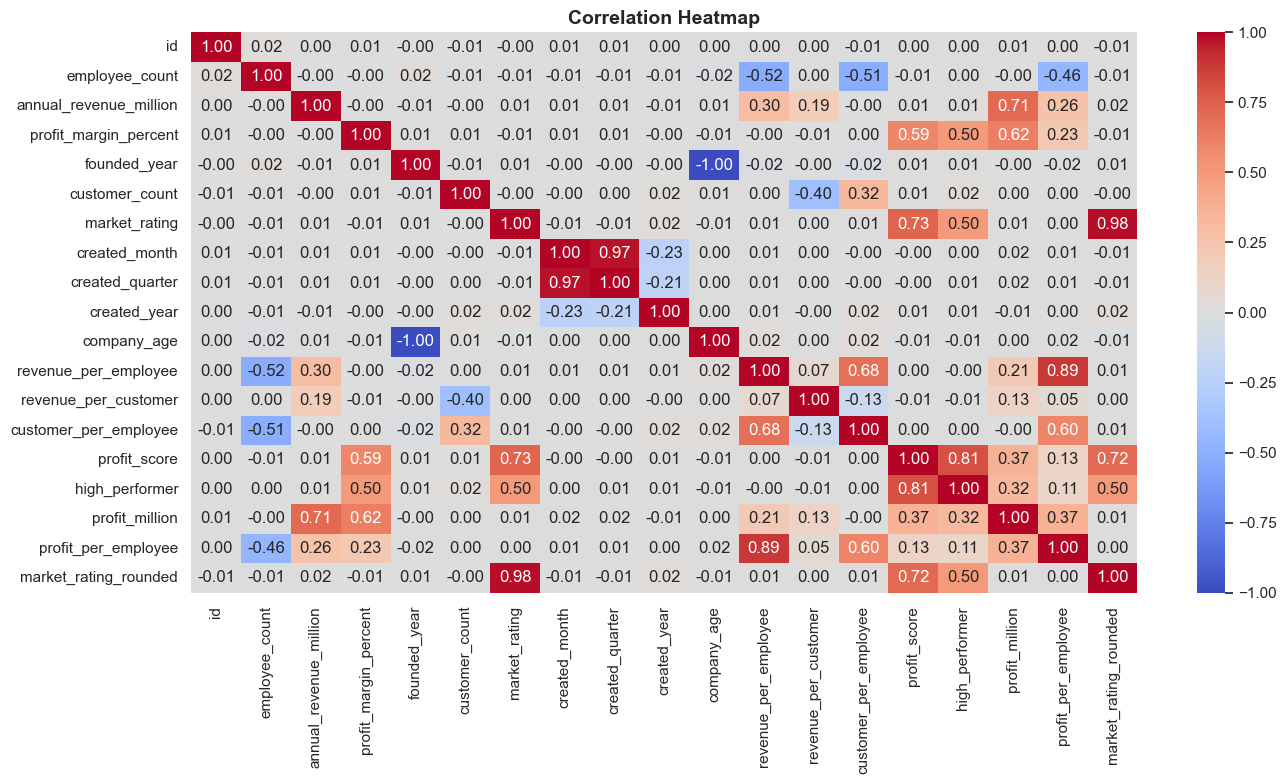

In [68]:
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(14,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

* The heatmap reveals that most business variables have weak relationships with one another, indicating that revenue, customers, employees, and market ratings largely vary independently in this dataset. This explains why several earlier visualizations did not show strong trends or clear patterns.
* Revenue per employee and profit per employee move closely together, suggesting that companies generating higher revenue from each employee also tend to achieve stronger profitability at the workforce level.
* Profit score is strongly associated with both market rating and profit margin percentage. This indicates that companies with better market perception and healthier margins generally achieve higher overall performance scores.
* Larger workforces appear to be linked with lower revenue and profit generated per employee. While bigger companies may have greater total resources, their efficiency at the employee level tends to be lower compared with smaller organizations.
* Customer-related efficiency metrics show more meaningful relationships than raw customer counts. This suggests that how effectively a company serves and monetizes its customers matters more than simply having a larger customer base.
* The strong relationship between the high-performer flag and profit-oriented metrics confirms that the feature successfully captures financially strong companies rather than randomly classifying businesses.

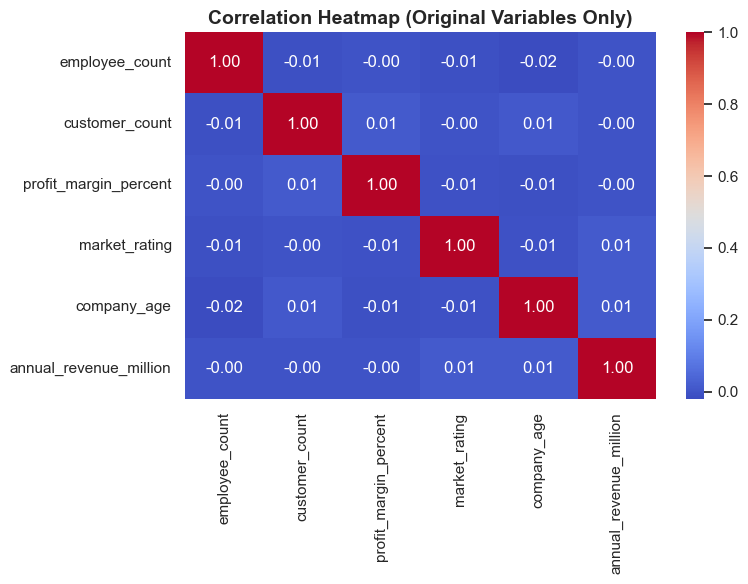

In [69]:
corr_cols = [
    "employee_count",
    "customer_count",
    "profit_margin_percent",
    "market_rating",
    "company_age",
    "annual_revenue_million"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap (Original Variables Only)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

* The heatmap shows that all original business variables have correlations very close to zero, indicating that none of them has a meaningful linear relationship with annual revenue. Revenue appears to behave independently of employee count, customer count, profit margin, market rating, and company age within this dataset.
* The absence of strong relationships suggests that company revenue is likely influenced by factors that are not captured in the available data. Variables such as pricing strategy, product portfolio, sales performance, marketing investment, and customer retention may play a more important role in explaining revenue differences.
* The weak correlations observed here provide a strong explanation for the poor performance of the machine learning models. Since the input features contain very little predictive signal, the models were unable to learn patterns capable of accurately forecasting annual revenue.

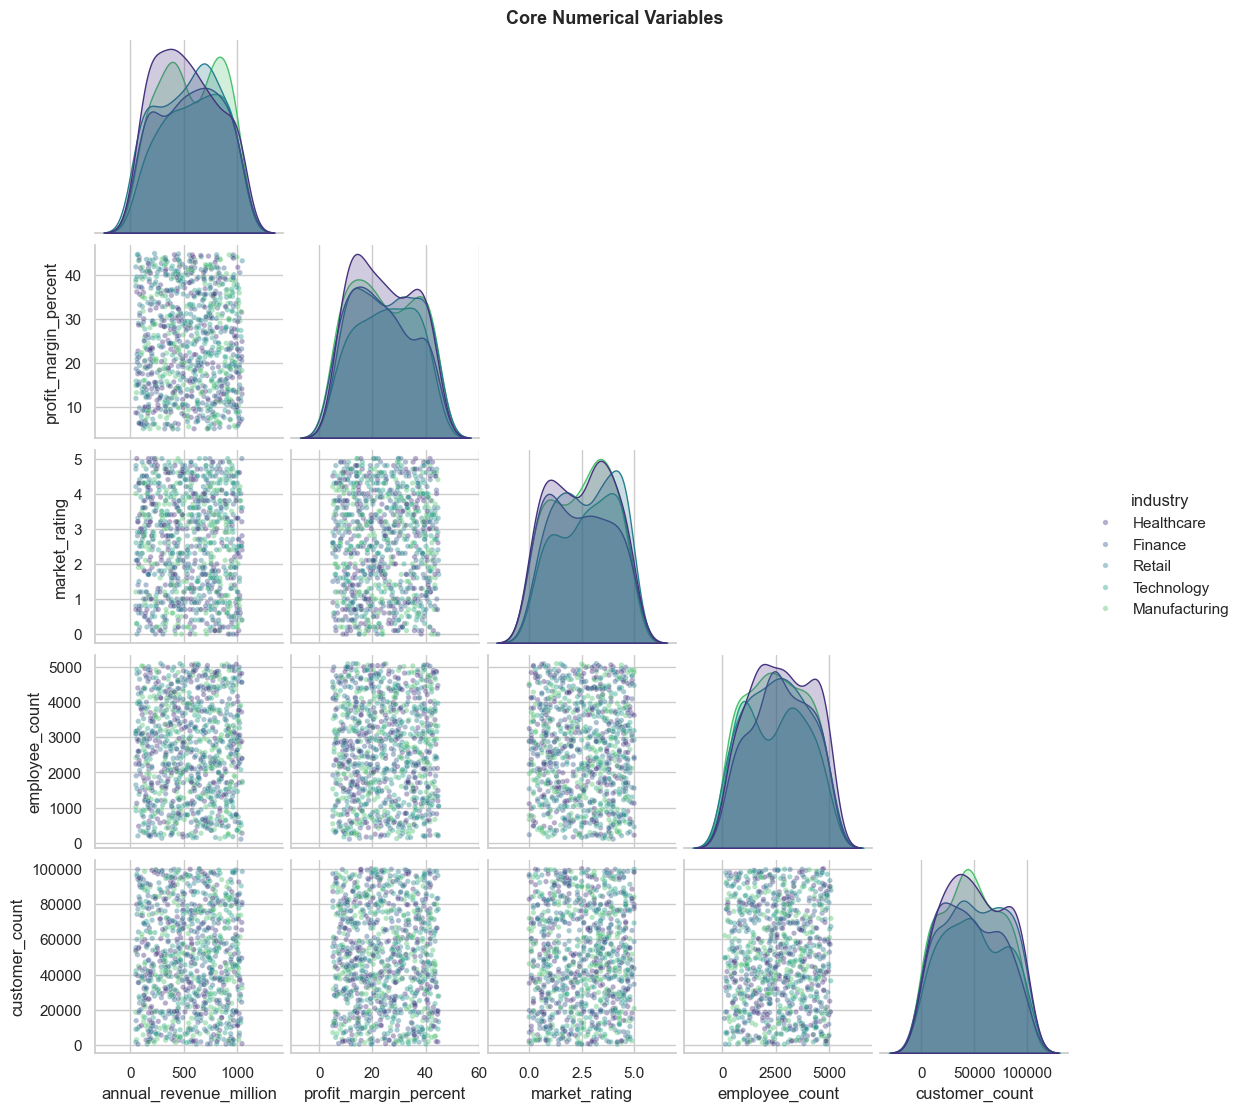

In [70]:
pair_cols = ["annual_revenue_million","profit_margin_percent",
            "market_rating","employee_count","customer_count","industry"]
sample    = df.sample(1000, random_state=42)

g = sns.pairplot(sample[pair_cols], hue="industry",
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15},
                 corner=True, height=2.2)
g.fig.suptitle("Core Numerical Variables",
               y=1.01, fontsize=13, fontweight="bold")
plt.show()

* The pair plot shows that companies from different industries are heavily mixed across all variables, with no clear industry-specific clusters. Finance, Technology, Retail, Manufacturing, and Healthcare companies occupy very similar ranges of revenue, profit margin, employee count, and customer count.
* Revenue, employee count, and customer count appear widely dispersed without forming obvious patterns or trends. Companies with high revenue can be found across both small and large workforce sizes, suggesting that employee count alone is not a strong indicator of revenue generation.
* The distributions along the diagonal are relatively similar across industries, indicating that no single industry consistently dominates in terms of revenue, profitability, workforce size, or customer volume.
* Market ratings are spread fairly evenly across all industries, reinforcing the idea that industry membership does not strongly influence customer or market perception within this dataset.
* The absence of visible clusters or strong directional relationships suggests that the major business variables operate largely independently. This observation is consistent with the correlation analysis, where most variable pairs showed weak correlations.
* Overall, the pair plot highlights that company performance characteristics are broadly distributed across industries rather than concentrated within a particular sector, making industry a relatively weak differentiator in this dataset.

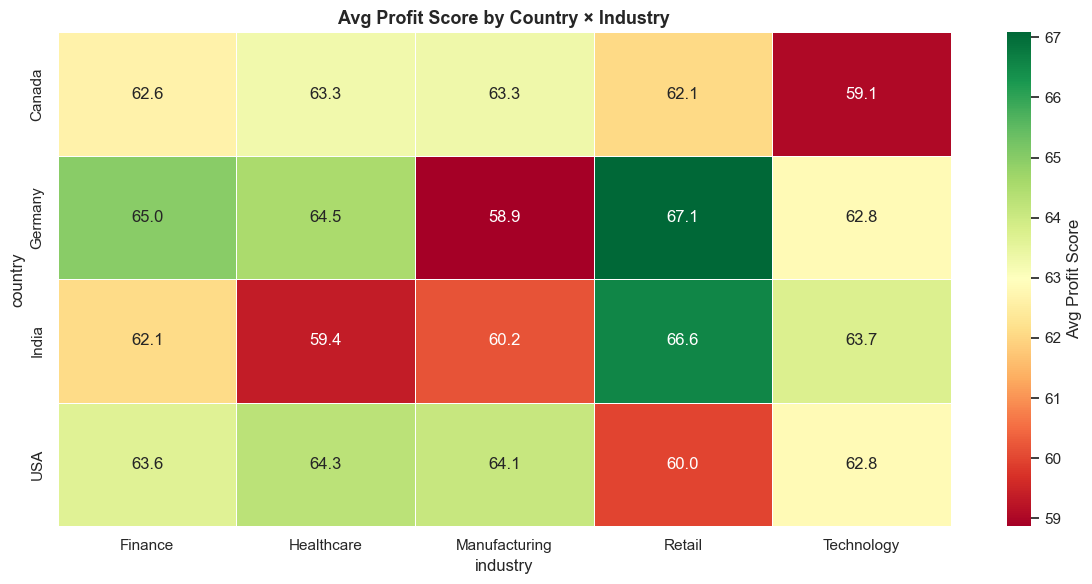

In [71]:
pivot2 = df.pivot_table(values="profit_score", index="country", columns="industry", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, ax=ax, cbar_kws={"label": "Avg Profit Score"})
ax.set_title("Avg Profit Score by Country × Industry", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

* Profit performance is not uniform across countries and industries. Some industries perform better in specific markets, while others show weaker results despite performing well elsewhere. Retail achieves its strongest profit scores in Germany and India, whereas Technology performs best in India and the USA. These differences suggest that profitability is influenced by the combination of industry and location rather than by either factor alone. The heatmap also reveals that industries with similar overall averages can still experience noticeably different outcomes across countries.

## Key Insights from Exploratory Data Analysis

* The dataset contains 15,000 companies from different industries, countries, and regions. During the analysis, we explored company size, customer base, revenue, profitability, market ratings, and several engineered features to better understand business performance.
* The overall distribution of the main numerical variables is balanced and does not show major data quality issues. Employee count, annual revenue, customer count, profit margin, market rating, and company age are spread evenly across their respective ranges. Outlier detection using both the IQR and Z-score methods did not identify significant outliers in the original business variables, indicating that the dataset is clean and stable for further analysis.
* The analysis showed that company size alone does not strongly influence annual revenue. Small, Mid, Large, and Enterprise companies all reported similar average revenue levels. A similar pattern was observed across countries, regions, and industries, where average revenue remained relatively consistent. This suggests that revenue performance is not dominated by a specific industry, country, or company size category.
* The violin plots and pair plots further confirmed that companies from different industries share very similar revenue and profitability distributions. No industry formed a clearly separate cluster, indicating that industry membership alone is not a strong differentiator of company performance in this dataset.
* Several engineered features provided deeper business insights. Revenue per employee, profit per employee, and profit score revealed larger differences between companies than raw company size or customer counts. These efficiency-related measures appear to capture business performance more effectively than simple scale metrics.
* The correlation analysis showed that most original business variables have weak relationships with one another. Annual revenue has very low correlation with employee count, customer count, company age, industry, country, and region. This explains why many scatter plots did not reveal strong trends or patterns.
* Company age was also found to have little relationship with revenue or profitability. Older companies do not consistently outperform newer companies, suggesting that years in operation alone are not a strong indicator of business success within this dataset.
* Profitability-related variables emerged as the most informative features. Profit score showed strong positive relationships with market rating and profit margin percentage. Companies with stronger margins and better market ratings generally achieved higher performance scores.
* The high-performer classification also validated this observation. Companies classified as high performers tended to have both above-average profit margins and stronger market ratings. This indicates that business success in the dataset is more closely linked to efficiency and profitability than to company size or age.
* The country-by-industry profitability analysis revealed that some industries perform differently depending on location. Although overall revenue remains relatively stable across countries, profit performance varies more noticeably when industry and geography are considered together. This suggests that market conditions may influence profitability more than revenue generation.
* Overall, the analysis indicates that efficiency measures, profit margins, market perception, and profitability metrics are more important indicators of company performance than workforce size, customer volume, company age, industry type, or geographic location.

## Business Recommendations

* Companies should focus on improving profitability and operational efficiency rather than simply increasing employee count or expanding their customer base. The analysis suggests that larger organizations do not automatically generate better revenue or profit outcomes.
* Improving profit margins should be a key business priority because profitability shows a strong connection with overall company performance. Businesses that manage costs effectively and maintain healthy margins are more likely to achieve stronger results.
* Market reputation also plays an important role. Companies with higher market ratings consistently achieve better performance scores. Investments in customer satisfaction, product quality, and brand reputation may therefore contribute to stronger business outcomes.
* Management teams should monitor efficiency-based metrics such as revenue per employee and profit per employee. These measures provide a clearer picture of business effectiveness than total employee count or total customer volume alone.
* Since company age showed little influence on performance, organizations should avoid assuming that experience alone creates competitive advantage. Continuous improvement and operational excellence appear to be more important than the number of years a company has been operating.
* The differences observed across country and industry combinations suggest that businesses should evaluate profitability at a market level rather than relying only on overall company averages. Identifying high-performing markets and industry segments may help companies allocate resources more effectively.
* Finally, future business decisions should prioritize factors related to profitability, efficiency, and market perception, as these variables demonstrated the strongest connection with overall company performance throughout the analysis.

## 10. Feature encoding and build model

In [72]:
cat_cols = ["industry", "country", "region"]

for col in cat_cols:

    le = LabelEncoder()

    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    print(f"{col}:", dict(zip(le.classes_, le.transform(le.classes_))))

industry: {'Finance': np.int64(0), 'Healthcare': np.int64(1), 'Manufacturing': np.int64(2), 'Retail': np.int64(3), 'Technology': np.int64(4)}
country: {'Canada': np.int64(0), 'Germany': np.int64(1), 'India': np.int64(2), 'USA': np.int64(3)}
region: {'Asia': np.int64(0), 'Europe': np.int64(1), 'North America': np.int64(2)}


In [73]:
FEATURES = [
    "employee_count",
    "customer_count",
    "profit_margin_percent",
    "market_rating",
    "company_age",
    "created_month",
    "created_quarter",
    "created_year",
    "industry_enc",
    "country_enc",
    "region_enc"
]

TARGET = "annual_revenue_million"

X = df[FEATURES]
y = df[TARGET]

print("Features:", len(FEATURES))
print("Target:", TARGET)

Features: 11
Target: annual_revenue_million


* During feature selection, some engineered variables such as profit_million, revenue_per_employee, revenue_per_customer, and profit_per_employee were excluded from model training. Although these variables showed higher correlations with the target variable, they were derived directly from annual_revenue_million. Using them would introduce data leakage because the target information is already embedded in these features. As a result, the model could achieve artificially high performance without learning meaningful business patterns. Therefore, only independent features available before knowing the revenue were used for prediction.

In [74]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42)

print("Train:", X_tr.shape)
print("Test :", X_te.shape)

Train: (12000, 11)
Test : (3000, 11)


In [75]:
regressors = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(max_depth=8, random_state=42),

    "Random Forest":
        RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),

    "Gradient Boosting":
        GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42),

    "Extra Trees":
        ExtraTreesRegressor(n_estimators=150, random_state=42, n_jobs=-1)}

In [76]:
results = []

print(
    f"{'Model':<22}"
    f"{'RMSE':>10}"
    f"{'MAE':>10}"
    f"{'R²':>10}"
)

print("─" * 58)

for name, model in regressors.items():

    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))

    mae = mean_absolute_error(y_te, preds)

    r2 = r2_score(y_te, preds)

    results.append([name, rmse, mae, r2])

    print(
        f"{name:<22}"
        f"{rmse:>10.3f}"
        f"{mae:>10.3f}"
        f"{r2:>10.4f}"
    )

Model                       RMSE       MAE        R²
──────────────────────────────────────────────────────────
Linear Regression        287.203   248.339   -0.0003
Decision Tree            290.067   250.219   -0.0204
Random Forest            287.572   248.573   -0.0029
Gradient Boosting        289.106   249.199   -0.0136
Extra Trees              291.622   250.215   -0.0313


* All regression models performed very poorly in predicting annual revenue.
* The best model, Linear Regression, achieved an R² score close to 0, while the remaining models produced negative R² values. This indicates that the selected features were unable to explain the variation in annual revenue. These results are consistent with the exploratory data analysis, which showed that most variables had very weak correlations with the target. Therefore, the available independent features do not provide sufficient predictive power for accurate revenue forecasting in this dataset.

In [77]:
corr_target = (
    df.select_dtypes(include="number")
      .corr()["annual_revenue_million"]
      .sort_values(ascending=False)
)

print(corr_target)

annual_revenue_million    1.000000
profit_million            0.711298
revenue_per_employee      0.300263
profit_per_employee       0.264840
revenue_per_customer      0.186484
market_rating_rounded     0.015441
market_rating             0.014639
company_age               0.011840
high_performer            0.011290
profit_score              0.008438
created_quarter           0.007977
created_month             0.007705
country_enc               0.007639
industry_enc              0.003876
id                        0.002347
region_enc               -0.000336
employee_count           -0.002043
customer_count           -0.002673
profit_margin_percent    -0.003120
customer_per_employee    -0.004000
created_year             -0.008456
founded_year             -0.011840
Name: annual_revenue_million, dtype: float64


* Correlation analysis showed that most independent variables had extremely weak relationships with annual revenue. Features such as employee count, customer count, market rating, company age, industry, country, and region all had correlation values very close to zero, indicating little influence on revenue.
* Although some engineered features such as profit_million, revenue_per_employee, and profit_per_employee showed higher correlations, they were excluded from model training because they were derived from annual revenue itself and would introduce data leakage. This explains why the machine learning models were unable to achieve meaningful predictive performance.

In [78]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "R2"]
)

best_row = results_df.loc[results_df["R2"].idxmax()]

print(
    f"\n★ Best Regressor: "
    f"{best_row['Model']} "
    f"(R² = {best_row['R2']:.4f})"
)


★ Best Regressor: Linear Regression (R² = -0.0003)


* Linear Regression achieved the highest R² score among all tested models and was therefore selected as the best-performing regressor. However, its R² value remained close to zero, indicating that the model could not effectively explain the variation in annual revenue. This further confirms that the available features contain very limited predictive information for revenue forecasting.

### Final Conclusion

* The objective of this project was to predict annual company revenue using business-related features such as employee count, customer count, profit margin, market rating, company age, industry, country, and region. Exploratory Data Analysis revealed that most variables had very weak relationships with annual revenue. Correlation analysis further confirmed that the majority of independent features had correlation values close to zero.
* Several regression models were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and Extra Trees. All models achieved R² scores close to zero or negative values, indicating poor predictive performance. This suggests that the available features do not contain sufficient information to accurately predict annual revenue.
* Although some engineered variables showed stronger correlations with revenue, they were excluded from model training because they were derived from the target variable and would introduce data leakage. Therefore, the final results provide an honest assessment of the dataset and demonstrate that revenue forecasting is not feasible using the selected independent variables.

### Recommendation

* Since annual revenue could not be reliably predicted using the available variables, organizations should avoid making revenue forecasts based solely on factors such as company size, customer count, market rating, industry, or company age. Additional business drivers such as product pricing, sales volume, marketing spend, customer retention, operational costs, and market demand would likely be required to build a more effective revenue prediction model. Future analysis should focus on collecting richer business data to improve forecasting accuracy.